# Unified Model Comparison — Network Anomaly Detection

This notebook trains **six** anomaly-detection models on the same CIC-UNSW dataset
split and produces side-by-side comparison visualisations.

| # | Model | Type |
|---|-------|------|
| 1 | Isolation Forest | Unsupervised (benign-only) |
| 2 | Random Forest | Supervised (binary) |
| 3 | XGBoost | Supervised (binary) |
| 4 | KMeans | Unsupervised clustering |
| 5 | Hybrid IF + RF | Hybrid (unsupervised + supervised) |
| 6 | Hybrid XGBoost + KMeans | Hybrid (clustering + supervised) |

## 1 — Environment & Imports

In [2]:
import os, sys, warnings, contextlib, io
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV,
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, confusion_matrix, classification_report,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

project_root = Path.cwd()
if (project_root / "config.py").is_file():
    sys.path.insert(0, str(project_root))
elif (project_root.parent / "config.py").is_file():
    sys.path.insert(0, str(project_root.parent))
elif (project_root.parent.parent / "config.py").is_file():
    sys.path.insert(0, str(project_root.parent.parent))

from sklearn.decomposition import PCA

from config import (
    DATASET_FILE,
    FEATURES_FILE,
    LABELS_FILE,
    LABEL_COLUMN,
    RANDOM_STATE,
    PLOTS_DIR,
    MODELS_DIR,
)
from data.loader import load_data, preprocess_data
from models.ml_models import KMeansClassifier, HybridKMeansXGBoost

SEED = RANDOM_STATE
np.random.seed(SEED)

plt.style.use("seaborn-v0_8")
sns.set_palette("husl")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "font.size": 11})

PREFIX = "comparison"

MODEL_NAMES = [
    "Isolation Forest",
    "Random Forest",
    "XGBoost",
    "KMeans",
    "Hybrid IF+RF",
    "Hybrid XGB+KMeans",
]

print(f"Random seed : {SEED}")
print(f"Plots dir   : {PLOTS_DIR}")
print(f"Models dir  : {MODELS_DIR}")

Random seed : 42
Plots dir   : /Users/mac/Documents/TUS/Project/New/intelligent-nids/output/plots
Models dir  : /Users/mac/Documents/TUS/Project/New/intelligent-nids/output/models


### Hybrid IF+RF class (inline — not in shared module)

In [3]:
class HybridAnomalyDetector:
    """Two-stage Isolation Forest + Random Forest hybrid with meta-ensemble fusion."""

    def __init__(self, if_params=None, rf_params=None, fusion_method="weighted_vote"):
        self.if_params = if_params or {
            "n_estimators": 100, "contamination": 0.2,
            "max_samples": "auto", "random_state": SEED, "n_jobs": -1,
        }
        self.rf_params = rf_params or {
            "n_estimators": 100, "max_depth": 20, "min_samples_split": 5,
            "min_samples_leaf": 2, "class_weight": "balanced",
            "random_state": SEED, "n_jobs": -1,
        }
        self.fusion_method = fusion_method
        self.if_model = None
        self.rf_model = None
        self.rf_calibrated = None
        self.meta_model = None
        self.if_score_scaler = MinMaxScaler()
        self.w_if = 0.3
        self.w_rf = 0.7
        self.rule_threshold = 0.5
        self.feature_names_ = None

    def _if_anomaly_features(self, X):
        raw = self.if_model.decision_function(X)
        scores_norm = self.if_score_scaler.transform((-raw).reshape(-1, 1)).ravel()
        binary_flag = (self.if_model.predict(X) == -1).astype(int)
        return scores_norm, binary_flag

    def _enrich_features(self, X):
        score, flag = self._if_anomaly_features(X)
        return np.column_stack([X, score, flag])

    def fit(self, X_benign, X_labeled, y_labeled, X_val=None, y_val=None):
        print("[Stage 1] Training Isolation Forest on benign-only data …")
        self.if_model = IsolationForest(**self.if_params)
        self.if_model.fit(X_benign)
        print(f"  IF fitted on {X_benign.shape[0]:,} benign samples.")

        raw_scores = self.if_model.decision_function(X_labeled)
        self.if_score_scaler.fit((-raw_scores).reshape(-1, 1))

        print("[Stage 2] Training Random Forest on enriched features …")
        X_enriched = self._enrich_features(X_labeled)
        self.rf_model = RandomForestClassifier(**self.rf_params)
        self.rf_model.fit(X_enriched, y_labeled)
        print(f"  RF fitted on {X_enriched.shape[0]:,} samples, {X_enriched.shape[1]} features.")

        print("[Stage 2b] Calibrating RF probabilities (Platt scaling) …")
        self.rf_calibrated = CalibratedClassifierCV(self.rf_model, method="sigmoid", cv=3)
        self.rf_calibrated.fit(X_enriched, y_labeled)

        if X_val is not None and y_val is not None:
            self._fit_fusion(X_val, y_val)
        else:
            _, X_meta, _, y_meta = train_test_split(
                X_labeled, y_labeled, test_size=0.2, stratify=y_labeled, random_state=SEED
            )
            self._fit_fusion(X_meta, y_meta)

        print("[Done] Hybrid IF+RF model fitted.\n")
        return self

    def _fit_fusion(self, X_val, y_val):
        if_score_val, _ = self._if_anomaly_features(X_val)
        X_enriched_val = self._enrich_features(X_val)
        rf_proba_val = self.rf_calibrated.predict_proba(X_enriched_val)[:, 1]

        if self.fusion_method == "weighted_vote":
            print("[Stage 3] Tuning weighted-vote fusion weights …")
            best_f1, best_w = -1, 0.5
            for w in np.arange(0.0, 1.01, 0.05):
                combined = w * if_score_val + (1 - w) * rf_proba_val
                preds = (combined >= 0.5).astype(int)
                score = f1_score(y_val, preds)
                if score > best_f1:
                    best_f1, best_w = score, w
            self.w_if = best_w
            self.w_rf = 1 - best_w
            print(f"  Best weights: w_IF={self.w_if:.2f}  w_RF={self.w_rf:.2f}  (val F1={best_f1:.4f})")

        elif self.fusion_method == "stacking":
            print("[Stage 3] Training stacking meta-learner …")
            meta_X = np.column_stack([if_score_val, rf_proba_val])
            self.meta_model = LogisticRegression(random_state=SEED, max_iter=1000, class_weight="balanced")
            self.meta_model.fit(meta_X, y_val)
            print(f"  Meta-learner val F1={f1_score(y_val, self.meta_model.predict(meta_X)):.4f}")

        elif self.fusion_method == "rule_based":
            print("[Stage 3] Tuning rule-based threshold …")
            if_flag_val = (self.if_model.predict(X_val) == -1).astype(int)
            best_f1, best_thr = -1, 0.5
            for thr in np.arange(0.1, 0.91, 0.05):
                preds = ((if_flag_val == 1) & (rf_proba_val >= thr)).astype(int)
                remaining = if_flag_val == 0
                preds[remaining] = (rf_proba_val[remaining] >= 0.8).astype(int)
                sc = f1_score(y_val, preds)
                if sc > best_f1:
                    best_f1, best_thr = sc, thr
            self.rule_threshold = best_thr
            print(f"  Best rule threshold: {self.rule_threshold:.2f}  (val F1={best_f1:.4f})")

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

    def predict_proba(self, X):
        if_score, if_flag = self._if_anomaly_features(X)
        X_enriched = self._enrich_features(X)
        rf_proba = self.rf_calibrated.predict_proba(X_enriched)[:, 1]

        if self.fusion_method == "weighted_vote":
            return self.w_if * if_score + self.w_rf * rf_proba
        elif self.fusion_method == "stacking":
            meta_X = np.column_stack([if_score, rf_proba])
            return self.meta_model.predict_proba(meta_X)[:, 1]
        elif self.fusion_method == "rule_based":
            result = np.zeros(len(X))
            flagged = if_flag == 1
            result[flagged] = np.where(
                rf_proba[flagged] >= self.rule_threshold,
                rf_proba[flagged], rf_proba[flagged] * 0.8,
            )
            result[~flagged] = rf_proba[~flagged] * 0.5
            return result
        raise ValueError(f"Unknown fusion_method: {self.fusion_method}")

    def get_feature_importances(self, feature_names):
        enriched_names = list(feature_names) + ["IF_anomaly_score", "IF_anomaly_flag"]
        importances = self.rf_model.feature_importances_
        return pd.DataFrame({
            "feature": enriched_names, "importance": importances,
        }).sort_values("importance", ascending=False).reset_index(drop=True)

print("HybridAnomalyDetector class defined.")

HybridAnomalyDetector class defined.


## 2 — Data Loading & Preprocessing

- Load features + labels CSVs, create **binary** labels (`0`=benign, `1`=attack).
- **70 / 30** stratified train / test split.
- Extract **benign-only** subset from training data (for IF and Hybrid IF+RF).
- Further split training into **train / val** (75 / 25) for models that need validation.
- `StandardScaler` fit on training data; transform all splits.

In [4]:
X_df = pd.read_csv(FEATURES_FILE, low_memory=False)
X_df.columns = X_df.columns.str.strip()
y_df = pd.read_csv(LABELS_FILE, low_memory=False)
y_df.columns = y_df.columns.str.strip()

label_col = LABEL_COLUMN if LABEL_COLUMN in y_df.columns else y_df.columns[0]
y_raw = y_df[label_col]
y = (y_raw != 0).astype(int)

feature_cols = X_df.columns.tolist()
df = X_df.copy()
df["Label"] = y

print(f"Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} cols ({len(feature_cols)} features)")
print(f"Class balance : benign={int((y == 0).sum()):,}  attack={int((y == 1).sum()):,}")
print(f"Attack ratio  : {y.mean():.2%}")
df.head(3)

Dataset shape : 447,915 rows × 77 cols (76 features)
Class balance : benign=358,332  attack=89,583
Attack ratio  : 20.00%


,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,214392,9,21,388.0,24564.0,194.0,0.0,43.111111,85.545959,1460.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,2376792,9,3,752.0,0.0,188.0,0.0,83.555556,99.084700,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,131350,10,3,7564.0,0.0,1460.0,0.0,756.400000,690.497277,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [5]:
X_raw = X_df.values.astype(float)
X_raw = np.where(np.isinf(X_raw), np.nan, X_raw)
X_raw = np.nan_to_num(X_raw, nan=0.0)
X_raw = np.clip(X_raw, -1e10, 1e10)
y_all = y.values

X_train_full, X_test_raw, y_train_full, y_test = train_test_split(
    X_raw, y_all, test_size=0.3, stratify=y_all, random_state=SEED
)

benign_mask = y_train_full == 0
X_train_benign_raw = X_train_full[benign_mask]

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, stratify=y_train_full, random_state=SEED
)

scaler = StandardScaler()
scaler.fit(X_train_benign_raw)

X_train = scaler.transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)
X_train_benign = scaler.transform(X_train_benign_raw)
X_train_full_scaled = scaler.transform(X_train_full)

contamination_est = float(np.clip(y_train_full.mean(), 0.01, 0.5))

print(f"Train        : {X_train.shape[0]:,} samples  (benign {(y_train==0).sum():,} | attack {(y_train==1).sum():,})")
print(f"Validation   : {X_val.shape[0]:,} samples")
print(f"Test         : {X_test.shape[0]:,} samples")
print(f"Benign-only  : {X_train_benign.shape[0]:,} samples")
print(f"Contamination: {contamination_est:.4f}")

Train        : 235,155 samples  (benign 188,124 | attack 47,031)
Validation   : 78,385 samples
Test         : 134,375 samples
Benign-only  : 250,832 samples
Contamination: 0.2000


## 3 — EDA Overview

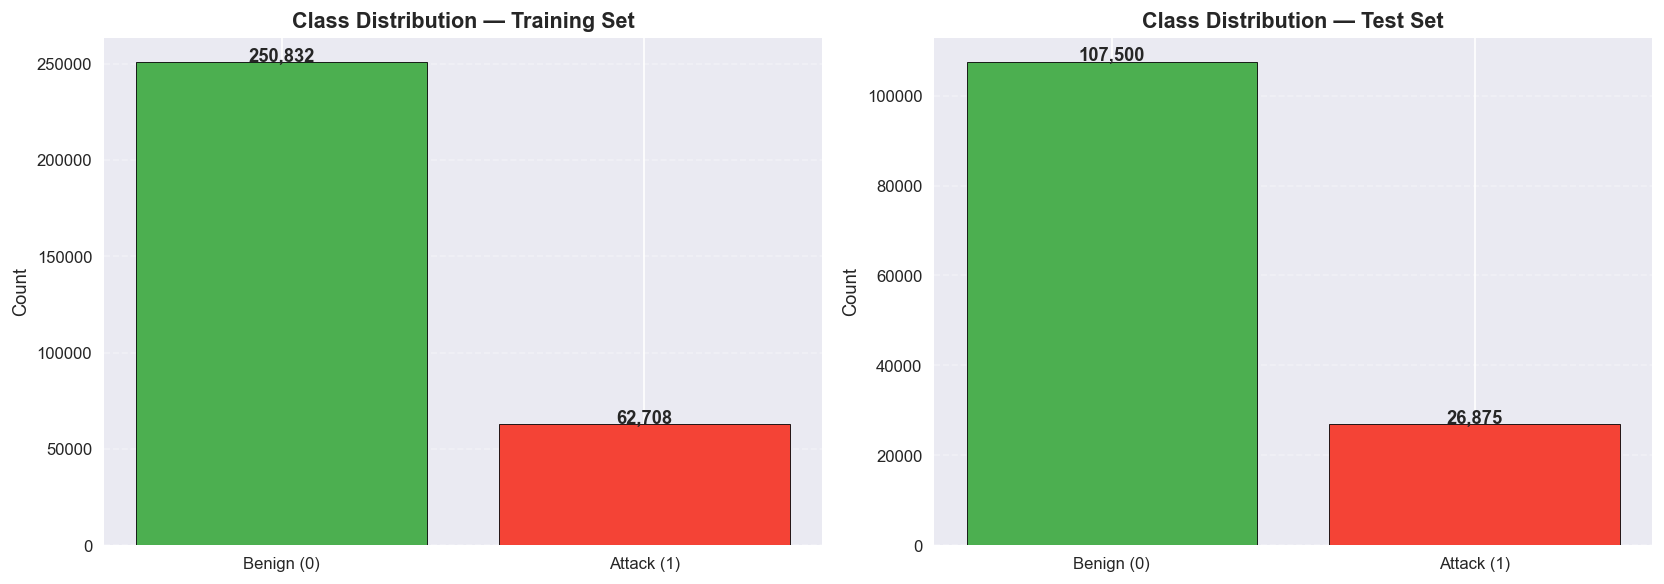

Saved to /Users/mac/Documents/TUS/Project/New/intelligent-nids/output/plots/comparison_eda_class_distribution.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (labels, title) in zip(axes, [
    (y_train_full, "Training Set"), (y_test, "Test Set"),
]):
    counts = pd.Series(labels).value_counts().sort_index()
    bars = ax.bar(["Benign (0)", "Attack (1)"], counts.values,
                  color=["#4CAF50", "#F44336"], edgecolor="black", linewidth=0.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
                f"{val:,}", ha="center", fontweight="bold")
    ax.set_title(f"Class Distribution — {title}", fontsize=13, fontweight="bold")
    ax.set_ylabel("Count")
    ax.grid(axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig(PLOTS_DIR / f"{PREFIX}_eda_class_distribution.png", bbox_inches="tight")
plt.show()
print(f"Saved to {PLOTS_DIR / f'{PREFIX}_eda_class_distribution.png'}")

## 4 — Train All Models

Each model is trained below and its predictions / scores stored in a unified `results` dict.

In [7]:
results = {}

# --- 1. Isolation Forest ---
print("=" * 70)
print("Training Isolation Forest (benign-only) …")
print("=" * 70)
iso_forest = IsolationForest(
    n_estimators=100, contamination=contamination_est,
    max_samples="auto", random_state=SEED, n_jobs=-1,
)
iso_forest.fit(X_train_benign)

if_pred_raw = iso_forest.predict(X_test)
if_pred = (if_pred_raw == -1).astype(int)
if_scores_raw = -iso_forest.decision_function(X_test)
if_score_scaler = MinMaxScaler()
if_score_scaler.fit(-iso_forest.decision_function(X_train_full_scaled).reshape(-1, 1))
if_scores_norm = if_score_scaler.transform(if_scores_raw.reshape(-1, 1)).ravel()

results["Isolation Forest"] = {
    "model": iso_forest, "y_pred": if_pred, "y_proba": if_scores_norm,
}
print(f"  Done. Test accuracy: {accuracy_score(y_test, if_pred):.4f}\n")

Training Isolation Forest (benign-only) …
  Done. Test accuracy: 0.7876



In [8]:
# --- 2. Random Forest ---
print("=" * 70)
print("Training Random Forest …")
print("=" * 70)
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=20, min_samples_split=5,
    min_samples_leaf=2, class_weight="balanced",
    random_state=SEED, n_jobs=-1,
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

results["Random Forest"] = {
    "model": rf_model, "y_pred": rf_pred, "y_proba": rf_proba,
}
print(f"  Done. Test accuracy: {accuracy_score(y_test, rf_pred):.4f}\n")

Training Random Forest …
  Done. Test accuracy: 0.9824



In [9]:
# --- 3. XGBoost ---
print("=" * 70)
print("Training XGBoost …")
print("=" * 70)
xgb_model = XGBClassifier(
    n_estimators=100, max_depth=12, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric="logloss",
    random_state=SEED, n_jobs=-1,
)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

results["XGBoost"] = {
    "model": xgb_model, "y_pred": xgb_pred, "y_proba": xgb_proba,
}
print(f"  Done. Test accuracy: {accuracy_score(y_test, xgb_pred):.4f}\n")

Training XGBoost …
  Done. Test accuracy: 0.9831



### KMeans & Hybrid XGB+KMeans — pipeline (standalone notebooks)

`load_data` → `preprocess_data` → PCA(30), same hyperparameters as `x_kmeans_network_anomaly copy.ipynb` and `x_hybrid_xgbost_kmeans_network_anomaly.ipynb`.

In [10]:
# KMeans + Hybrid XGB+KMeans: pipeline aligned with standalone notebooks
apply_four_class_mapping = DATASET_FILE is not None and (
    FEATURES_FILE is None or LABELS_FILE is None
)

train_df_km, test_df_km = load_data(
    features_path=FEATURES_FILE,
    labels_path=LABELS_FILE,
    label_column=LABEL_COLUMN,
    test_size=0.3,
    random_state=SEED,
    output_dir=None,
)

X_train_km, y_train_km, label_encoders_km, scaler_km = preprocess_data(
    df=train_df_km,
    label_column=LABEL_COLUMN,
    fit_encoders=True,
    handle_missing=True,
    apply_four_class_mapping=apply_four_class_mapping,
)

X_test_km, y_test_km, _, _ = preprocess_data(
    df=test_df_km,
    label_column=LABEL_COLUMN,
    fit_encoders=False,
    label_encoders=label_encoders_km,
    scaler=scaler_km,
    handle_missing=True,
    apply_four_class_mapping=apply_four_class_mapping,
)

N_PCA_KM = 30
pca_km = PCA(n_components=N_PCA_KM, random_state=SEED)
X_train_pca_km = pca_km.fit_transform(X_train_km)
X_test_pca_km = pca_km.transform(X_test_km)
print(
    f"KMeans/Hybrid pipeline: PCA {N_PCA_KM} components → "
    f"{pca_km.explained_variance_ratio_.sum():.2%} variance explained"
)
print(f"  train {X_train_pca_km.shape}  test {X_test_pca_km.shape}")
print(f"  y_test_km: {len(y_test_km)} samples")

_KM_HP = {
    "n_clusters": 10,
    "anomaly_fraction_threshold": 0.4,
    "small_cluster_fraction_threshold": 0.02,
    "single_benign_cluster": False,
    "use_hungarian_mapping": True,
}

Loading features from /Users/mac/Documents/TUS/Project/New/intelligent-nids/new-dt/CIC-UNSW/Data.csv...
Features shape: (447915, 76)
Loading labels from /Users/mac/Documents/TUS/Project/New/intelligent-nids/new-dt/CIC-UNSW/Label.csv...
Labels shape: (447915, 1)
Merged dataset shape (features + label): (447915, 77)
Original overall class counts -> benign (0): 358332, attacks (1+): 89583

Rebalancing dataset to approximately 70/30 Benign/Attack by downsampling benign class...
Rebalanced dataset shape: (298610, 77)
New overall class distribution:
  0: 209027 (70.00%)
  1: 89583 (30.00%)

Splitting dataset into train/test with test_size=0.3, random_state=42...
Training data shape: (209027, 77)
Test data shape: (89583, 77)

Training set class distribution:
  0: 146319 (70.00%)
  1: 62708 (30.00%)

Test set class distribution:
  0: 62708 (70.00%)
  1: 26875 (30.00%)
KMeans/Hybrid pipeline: PCA 30 components → 98.94% variance explained
  train (209027, 30)  test (89583, 30)
  y_test_km: 89583

In [11]:
# --- 4. KMeans (PCA + HP aligned with standalone KMeans notebook) ---
print("=" * 70)
print("Training KMeans …")
print("=" * 70)
kmeans_model = KMeansClassifier(
    random_state=SEED,
    n_init=100,
    max_iter=500,
    **_KM_HP,
)
kmeans_model.fit(X_train_pca_km, y_train_km)

kmeans_pred = kmeans_model.predict(X_test_pca_km)
kmeans_proba = None  # KMeans has no probability scores

results["KMeans"] = {
    "model": kmeans_model, "y_pred": kmeans_pred, "y_proba": kmeans_proba,
}
print(f"  Cluster-to-class mapping: {kmeans_model.cluster_to_class_}")
print(f"  Done. Test accuracy: {accuracy_score(y_test_km, kmeans_pred):.4f}\n")

Training KMeans …
  Cluster-to-class mapping: [1 0 0 1 1 0 1 1 0 1]
  Done. Test accuracy: 0.7207



In [12]:
# --- 5. Hybrid IF+RF ---
print("=" * 70)
print("Training Hybrid IF+RF (weighted_vote) …")
print("=" * 70)
hybrid_ifrf = HybridAnomalyDetector(
    if_params={
        "n_estimators": 100, "contamination": contamination_est,
        "max_samples": "auto", "random_state": SEED, "n_jobs": -1,
    },
    rf_params={
        "n_estimators": 100, "max_depth": 20, "min_samples_split": 5,
        "min_samples_leaf": 2, "class_weight": "balanced",
        "random_state": SEED, "n_jobs": -1,
    },
    fusion_method="weighted_vote",
)
hybrid_ifrf.fit(X_train_benign, X_train, y_train, X_val, y_val)

hybrid_ifrf_pred = hybrid_ifrf.predict(X_test)
hybrid_ifrf_proba = hybrid_ifrf.predict_proba(X_test)

results["Hybrid IF+RF"] = {
    "model": hybrid_ifrf, "y_pred": hybrid_ifrf_pred, "y_proba": hybrid_ifrf_proba,
}
print(f"  Done. Test accuracy: {accuracy_score(y_test, hybrid_ifrf_pred):.4f}\n")

Training Hybrid IF+RF (weighted_vote) …
[Stage 1] Training Isolation Forest on benign-only data …
  IF fitted on 250,832 benign samples.
[Stage 2] Training Random Forest on enriched features …
  RF fitted on 235,155 samples, 78 features.
[Stage 2b] Calibrating RF probabilities (Platt scaling) …
[Stage 3] Tuning weighted-vote fusion weights …
  Best weights: w_IF=0.00  w_RF=1.00  (val F1=0.9579)
[Done] Hybrid IF+RF model fitted.

  Done. Test accuracy: 0.9829



In [13]:
# --- 6. Hybrid XGBoost + KMeans (aligned with standalone hybrid notebook) ---
print("=" * 70)
print("Training Hybrid XGBoost + KMeans …")
print("=" * 70)
hybrid_xgb_km = HybridKMeansXGBoost(
    n_clusters=_KM_HP["n_clusters"],
    distance_percentile=0.85,
    small_cluster_fraction=0.025,
    random_state=SEED,
    kmeans_kwargs={
        "n_init": 100,
        "max_iter": 500,
        "anomaly_fraction_threshold": _KM_HP["anomaly_fraction_threshold"],
        "small_cluster_fraction_threshold": _KM_HP["small_cluster_fraction_threshold"],
        "single_benign_cluster": _KM_HP["single_benign_cluster"],
        "use_hungarian_mapping": _KM_HP["use_hungarian_mapping"],
    },
    xgb_kwargs={
        "n_estimators": 150,
        "max_depth": 12,
        "learning_rate": 0.1,
        "use_label_encoder": False,
        "eval_metric": "mlogloss",
    },
)
hybrid_xgb_km.fit(X_train_pca_km, y_train_km)

hybrid_xgb_km_pred = hybrid_xgb_km.predict(X_test_pca_km)
try:
    proba_h = hybrid_xgb_km.predict_proba(X_test_pca_km)
    if proba_h.ndim == 2 and proba_h.shape[1] > 2:
        hybrid_xgb_km_proba = 1.0 - proba_h[:, 0]
    else:
        hybrid_xgb_km_proba = proba_h[:, 1]
except Exception:
    hybrid_xgb_km_proba = None

results["Hybrid XGB+KMeans"] = {
    "model": hybrid_xgb_km, "y_pred": hybrid_xgb_km_pred, "y_proba": hybrid_xgb_km_proba,
}
print(f"  Done. Test accuracy: {accuracy_score(y_test_km, hybrid_xgb_km_pred):.4f}\n")

print("=" * 70)
print("All 6 models trained successfully!")
print("=" * 70)

Training Hybrid XGBoost + KMeans …
  Done. Test accuracy: 0.7798

All 6 models trained successfully!


## 5 — Collect Metrics

In [14]:
def y_true_for_model(name):
    if name in ("KMeans", "Hybrid XGB+KMeans"):
        return y_test_km
    return y_test


def _score_for_auc(y_true, y_score):
    """Map model scores to benign-vs-attack ROC (multi-class: attack score = 1 - P(benign))."""
    if y_score is None:
        return None, None
    yt = np.asarray(y_true)
    ys = np.asarray(y_score)
    if ys.ndim == 2:
        ys = 1.0 - ys[:, 0]
    y_bin = (yt != 0).astype(int)
    if len(np.unique(y_bin)) < 2:
        return None, None
    return y_bin, ys


def compute_metrics(name, y_true, y_pred, y_score):
    yt = np.asarray(y_true)
    yp = np.asarray(y_pred)
    n_classes = len(np.unique(yt))
    avg = "binary" if n_classes == 2 else "weighted"

    # Benign (0) vs attack (>0) for detection-style TN/FP/FN/TP
    y_bin = (yt != 0).astype(int)
    p_bin = (yp != 0).astype(int)
    cm = confusion_matrix(y_bin, p_bin)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = fp = fn = tp = 0

    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    dr = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    y_auc, s_auc = _score_for_auc(y_true, y_score)
    auc = roc_auc_score(y_auc, s_auc) if y_auc is not None else None

    return {
        "Model": name,
        "Accuracy": accuracy_score(yt, yp),
        "Precision": precision_score(yt, yp, average=avg, zero_division=0),
        "Recall": recall_score(yt, yp, average=avg, zero_division=0),
        "F1-Score": f1_score(yt, yp, average=avg, zero_division=0),
        "AUC-ROC": auc,
        "Detection Rate": dr,
        "FPR": fpr_val,
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
    }

metrics_rows = []
for name in MODEL_NAMES:
    r = results[name]
    metrics_rows.append(
        compute_metrics(name, y_true_for_model(name), r["y_pred"], r["y_proba"])
    )

metrics_df = pd.DataFrame(metrics_rows)
display_cols = ["Model", "Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC", "Detection Rate", "FPR"]

try:
    styled = metrics_df[display_cols].style.format({
        "Accuracy": "{:.4f}", "Precision": "{:.4f}", "Recall": "{:.4f}",
        "F1-Score": "{:.4f}", "AUC-ROC": "{:.4f}", "Detection Rate": "{:.4f}", "FPR": "{:.4f}",
    }).set_caption("Performance Comparison — Test Set")
    display(styled)
except (AttributeError, ImportError):
    print("Performance Comparison — Test Set")
    display(metrics_df[display_cols])

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Detection Rate,FPR
0,Isolation Forest,0.7876,0.4800,0.7457,0.5841,0.8598,0.7457,0.2019
1,Random Forest,0.9824,0.9212,0.9971,0.9577,0.9961,0.9971,0.0213
2,XGBoost,0.9831,0.9302,0.9898,0.9591,0.9965,0.9898,0.0186
3,KMeans,0.7207,0.6347,0.1622,0.2584,nan,0.1622,0.0400
4,Hybrid IF+RF,0.9829,0.9308,0.9878,0.9584,0.9961,0.9878,0.0184
5,Hybrid XGB+KMeans,0.7798,0.9709,0.2742,0.4276,0.5775,0.2742,0.0035


## 6 — Evaluation & Comparison

### Visualisation 1 — Metrics Comparison Table

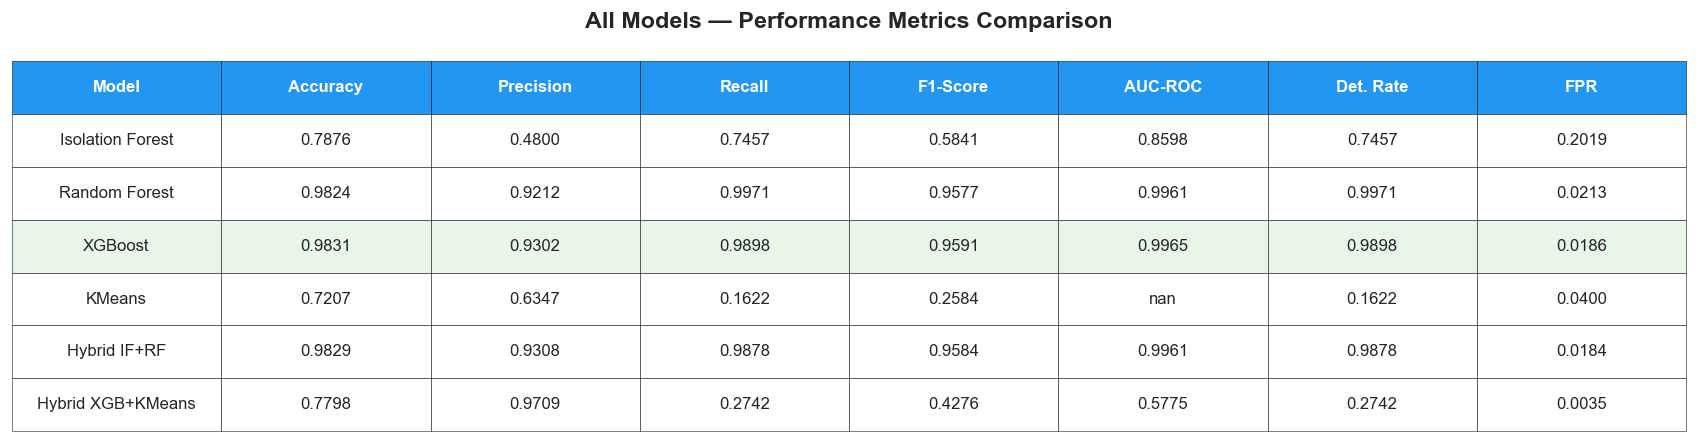

Saved to /Users/mac/Documents/TUS/Project/New/intelligent-nids/output/plots/comparison_metrics_table.png


In [15]:
fig, ax = plt.subplots(figsize=(18, 4))
ax.axis("off")

table_data = []
for _, row in metrics_df.iterrows():
    auc_str = f"{row['AUC-ROC']:.4f}" if row["AUC-ROC"] is not None else "N/A"
    table_data.append([
        row["Model"], f"{row['Accuracy']:.4f}", f"{row['Precision']:.4f}",
        f"{row['Recall']:.4f}", f"{row['F1-Score']:.4f}", auc_str,
        f"{row['Detection Rate']:.4f}", f"{row['FPR']:.4f}",
    ])

col_labels = ["Model", "Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC", "Det. Rate", "FPR"]
table = ax.table(cellText=table_data, colLabels=col_labels,
                 cellLoc="center", loc="center", bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
for i in range(len(col_labels)):
    table[(0, i)].set_facecolor("#2196F3")
    table[(0, i)].set_text_props(weight="bold", color="white")

best_idx = metrics_df["F1-Score"].idxmax()
for j in range(len(col_labels)):
    table[(best_idx + 1, j)].set_facecolor("#E8F5E9")

plt.title("All Models — Performance Metrics Comparison", fontsize=14, fontweight="bold", pad=20)
plt.savefig(PLOTS_DIR / f"{PREFIX}_metrics_table.png", bbox_inches="tight")
plt.show()
print(f"Saved to {PLOTS_DIR / f'{PREFIX}_metrics_table.png'}")

### Visualisation 2 — Anomaly Score / Probability Distributions

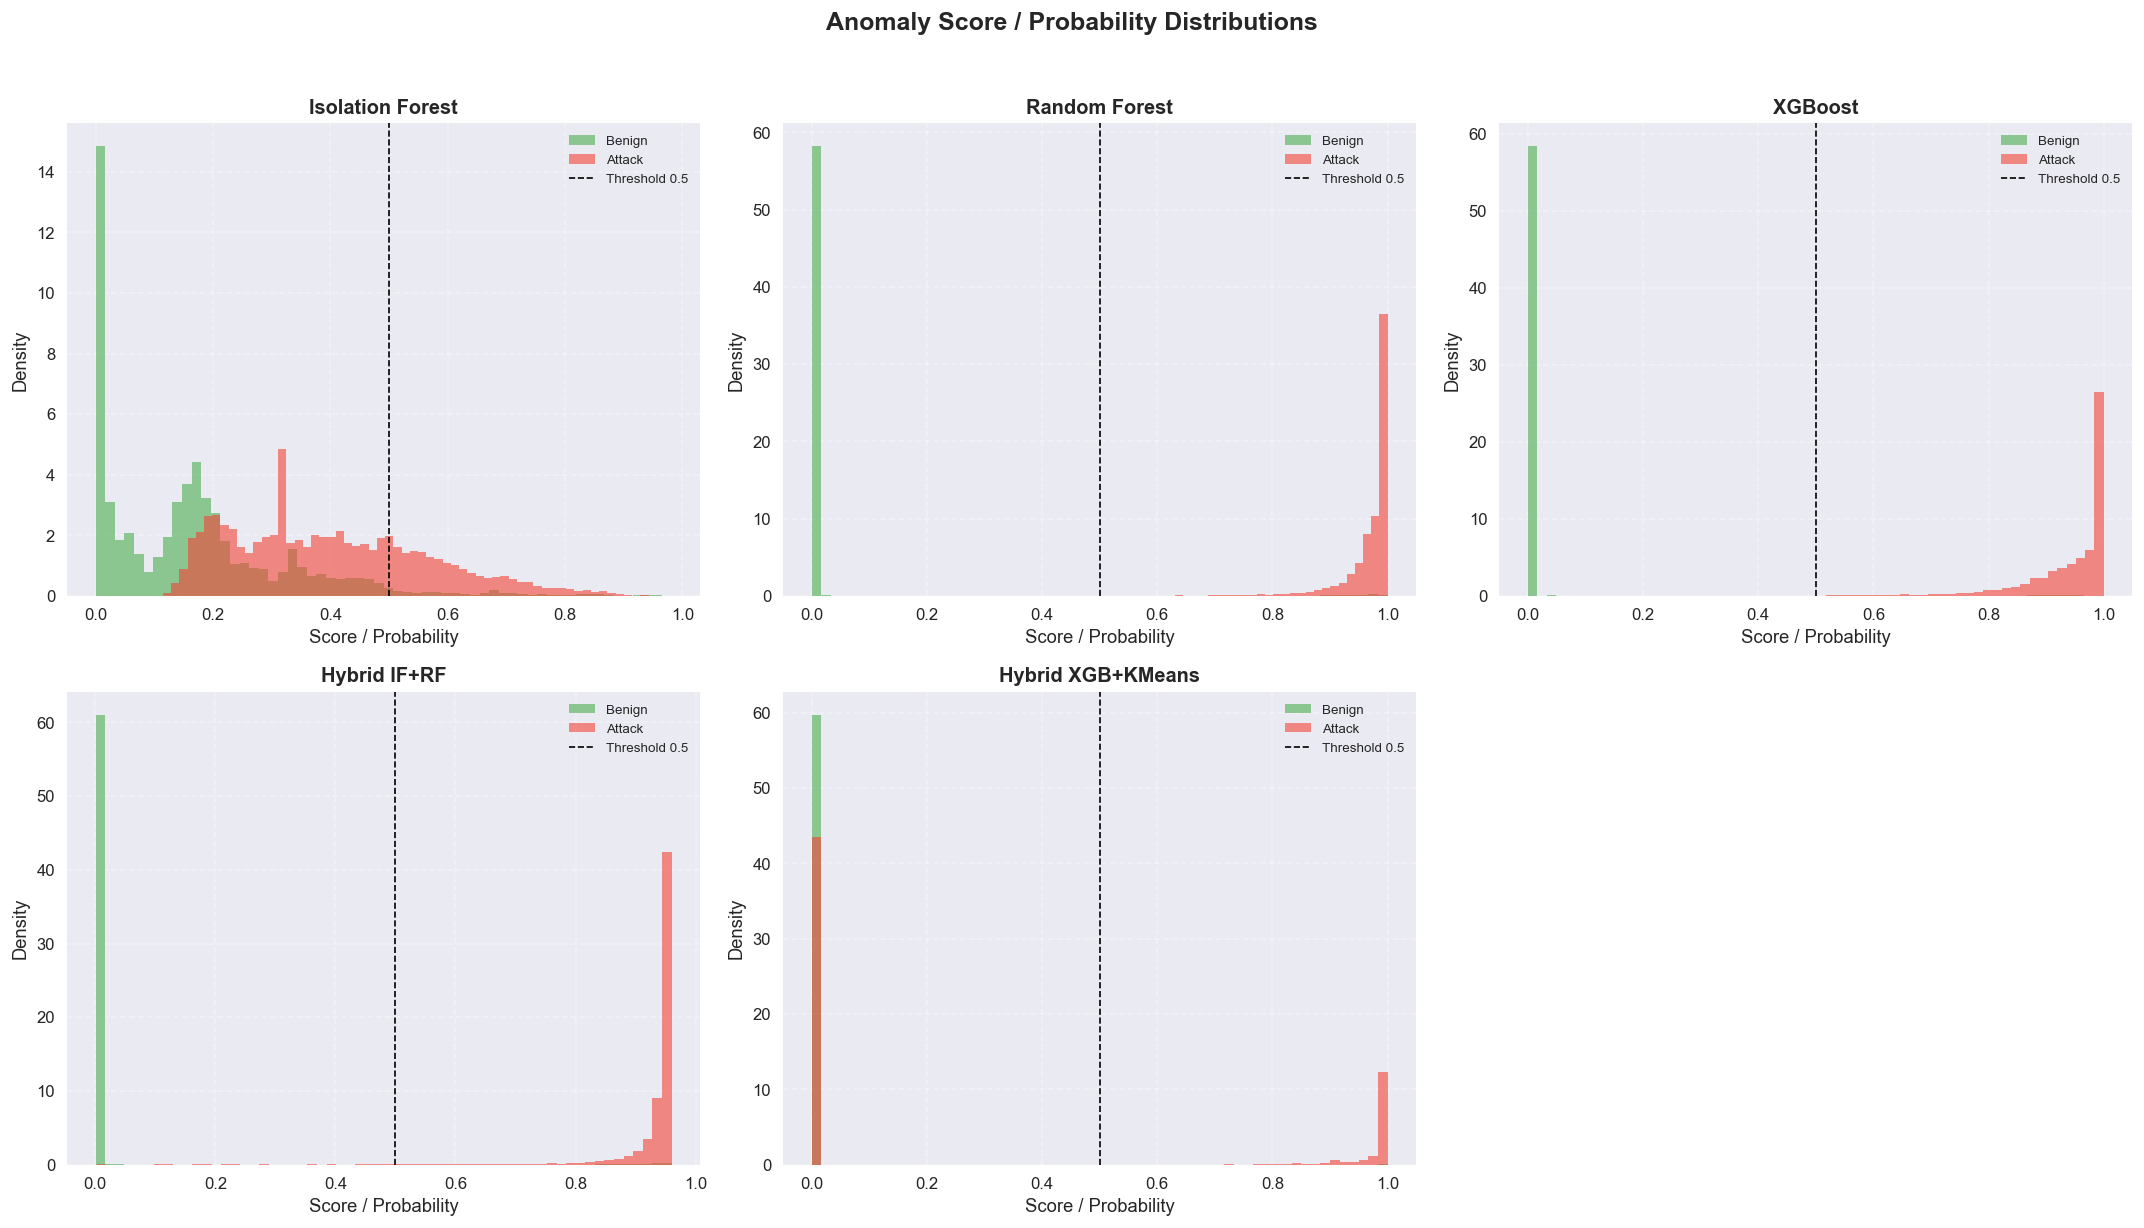

Saved to /Users/mac/Documents/TUS/Project/New/intelligent-nids/output/plots/comparison_score_distributions.png


In [16]:
score_models = {n: r["y_proba"] for n, r in results.items() if r["y_proba"] is not None}
n_score = len(score_models)
n_cols = 3
n_rows = (n_score + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = np.array(axes).flatten()

for i, (name, scores) in enumerate(score_models.items()):
    ax = axes[i]
    yt = y_true_for_model(name)
    benign_s = scores[yt == 0]
    attack_s = scores[yt != 0]
    ax.hist(benign_s, bins=60, alpha=0.6, label="Benign", color="#4CAF50", density=True)
    ax.hist(attack_s, bins=60, alpha=0.6, label="Attack", color="#F44336", density=True)
    ax.axvline(0.5, color="black", ls="--", lw=1, label="Threshold 0.5")
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Score / Probability")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, ls="--")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Anomaly Score / Probability Distributions", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"{PREFIX}_score_distributions.png", bbox_inches="tight")
plt.show()
print(f"Saved to {PLOTS_DIR / f'{PREFIX}_score_distributions.png'}")

### Visualisation 3 — ROC Curves

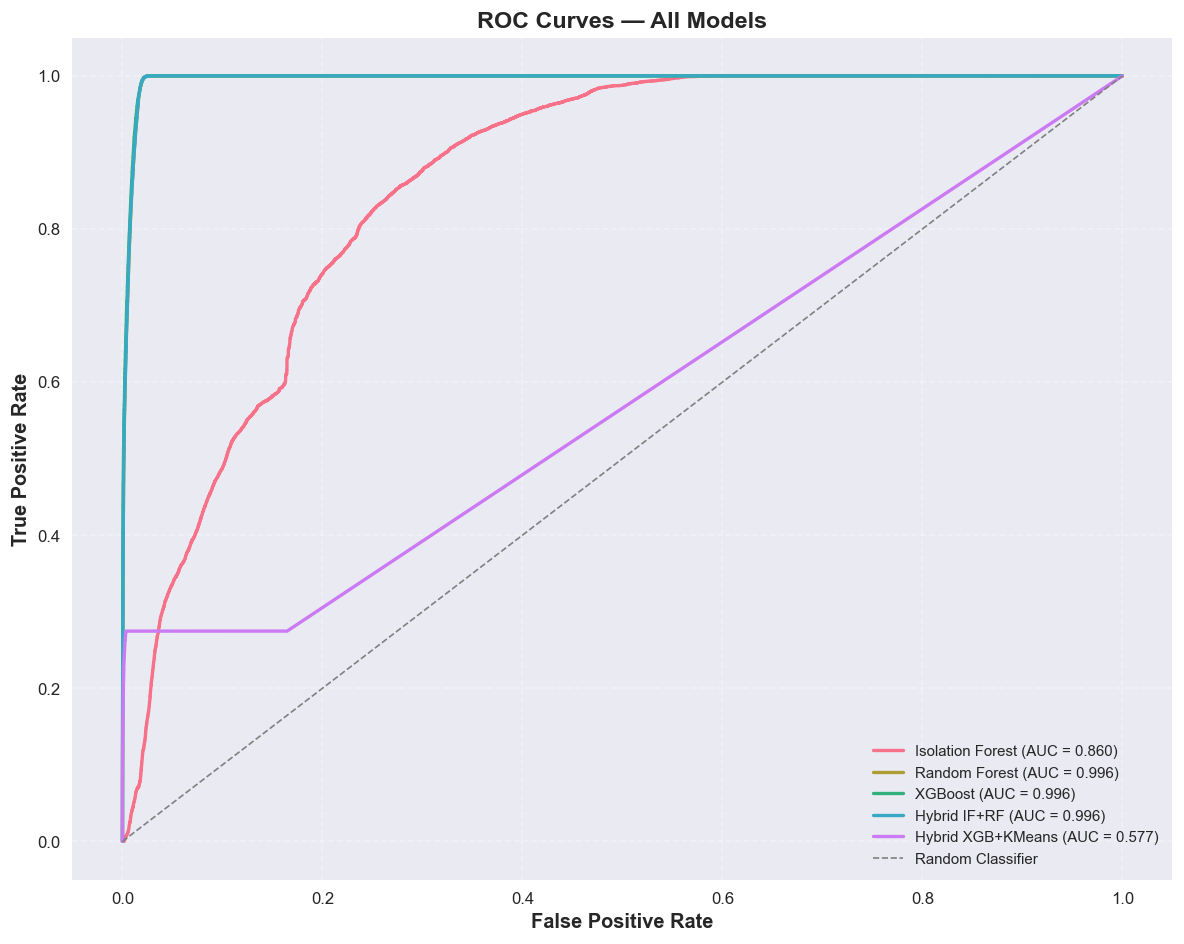

Saved to /Users/mac/Documents/TUS/Project/New/intelligent-nids/output/plots/comparison_roc_curves.png


In [17]:
fig, ax = plt.subplots(figsize=(10, 8))
colors = sns.color_palette("husl", n_score)

for (name, scores), color in zip(score_models.items(), colors):
    yt = np.asarray(y_true_for_model(name))
    ys = np.asarray(scores)
    if ys.ndim == 2:
        ys = 1.0 - ys[:, 0]
    y_bin = (yt != 0).astype(int)
    fpr, tpr, _ = roc_curve(y_bin, ys)
    auc = roc_auc_score(y_bin, ys)
    ax.plot(fpr, tpr, lw=2, color=color, label=f"{name} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], ls="--", color="gray", lw=1, label="Random Classifier")
ax.set_xlabel("False Positive Rate", fontsize=12, fontweight="bold")
ax.set_ylabel("True Positive Rate", fontsize=12, fontweight="bold")
ax.set_title("ROC Curves — All Models", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3, ls="--")

plt.tight_layout()
plt.savefig(PLOTS_DIR / f"{PREFIX}_roc_curves.png", bbox_inches="tight")
plt.show()
print(f"Saved to {PLOTS_DIR / f'{PREFIX}_roc_curves.png'}")

### Visualisation 4 — Precision-Recall Curves

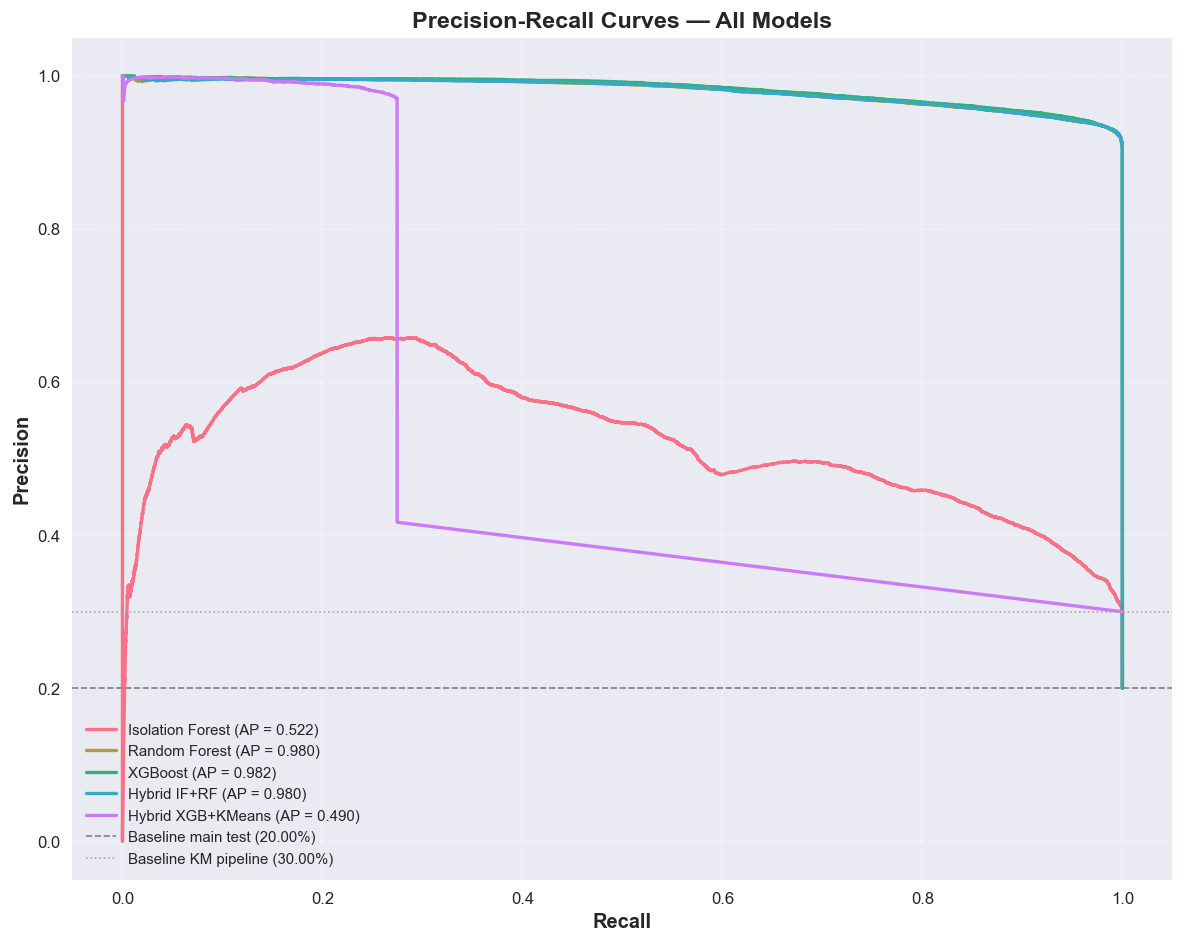

Saved to /Users/mac/Documents/TUS/Project/New/intelligent-nids/output/plots/comparison_precision_recall_curves.png


In [18]:
fig, ax = plt.subplots(figsize=(10, 8))
colors = sns.color_palette("husl", n_score)

for (name, scores), color in zip(score_models.items(), colors):
    yt = np.asarray(y_true_for_model(name))
    ys = np.asarray(scores)
    if ys.ndim == 2:
        ys = 1.0 - ys[:, 0]
    y_bin = (yt != 0).astype(int)
    prec_arr, rec_arr, _ = precision_recall_curve(y_bin, ys)
    ap = average_precision_score(y_bin, ys)
    ax.plot(rec_arr, prec_arr, lw=2, color=color, label=f"{name} (AP = {ap:.3f})")

ax.axhline(y_test.mean(), ls="--", color="gray", lw=1, label=f"Baseline main test ({y_test.mean():.2%})")
if abs(y_test.mean() - y_test_km.mean()) > 1e-6:
    ax.axhline(y_test_km.mean(), ls=":", color="darkgray", lw=1, label=f"Baseline KM pipeline ({y_test_km.mean():.2%})")
ax.set_xlabel("Recall", fontsize=12, fontweight="bold")
ax.set_ylabel("Precision", fontsize=12, fontweight="bold")
ax.set_title("Precision-Recall Curves — All Models", fontsize=14, fontweight="bold")
ax.legend(loc="lower left", fontsize=9)
ax.grid(alpha=0.3, ls="--")

plt.tight_layout()
plt.savefig(PLOTS_DIR / f"{PREFIX}_precision_recall_curves.png", bbox_inches="tight")
plt.show()
print(f"Saved to {PLOTS_DIR / f'{PREFIX}_precision_recall_curves.png'}")

### Visualisation 5 — Confusion Matrices (2 x 3 grid)

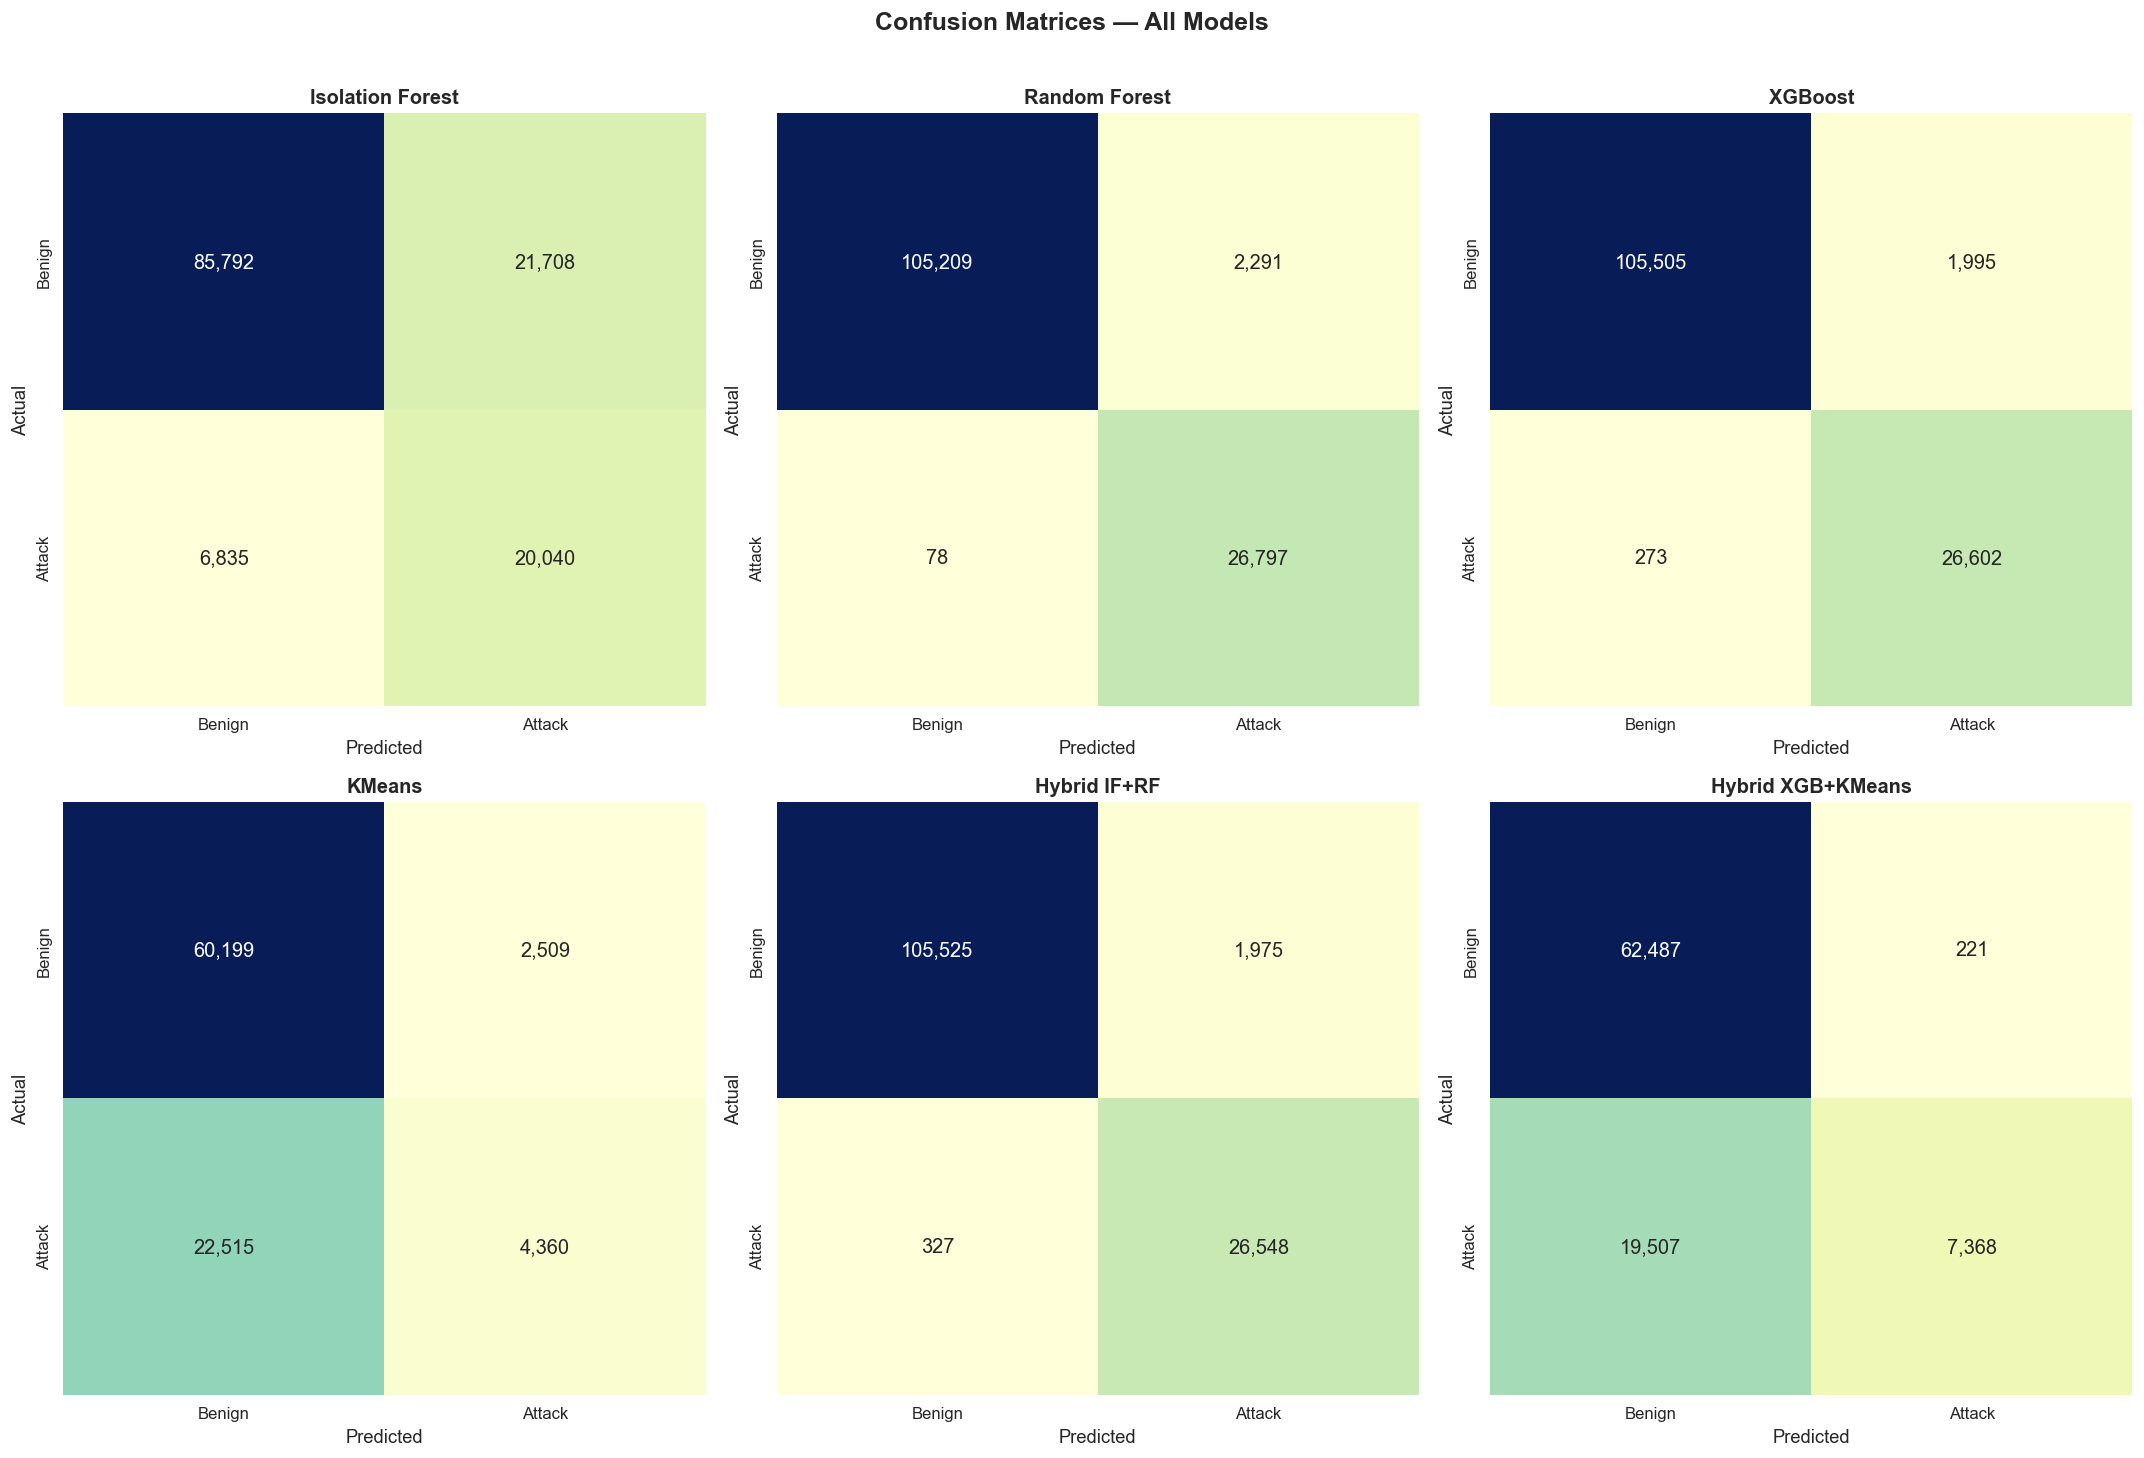

Saved to /Users/mac/Documents/TUS/Project/New/intelligent-nids/output/plots/comparison_confusion_matrices.png


In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, name in zip(axes, MODEL_NAMES):
    yt = np.asarray(y_true_for_model(name))
    yp = np.asarray(results[name]["y_pred"])
    y_bin = (yt != 0).astype(int)
    p_bin = (yp != 0).astype(int)
    cm = confusion_matrix(y_bin, p_bin)
    sns.heatmap(cm, annot=True, fmt=",d", cmap="YlGnBu",
                xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"],
                cbar=False, ax=ax, annot_kws={"size": 12})
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

fig.suptitle("Confusion Matrices — All Models", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"{PREFIX}_confusion_matrices.png", bbox_inches="tight")
plt.show()
print(f"Saved to {PLOTS_DIR / f'{PREFIX}_confusion_matrices.png'}")

### Visualisation 6 — Feature Importance Comparison

Only models with `feature_importances_` are shown: Random Forest, XGBoost, and Hybrid IF+RF.

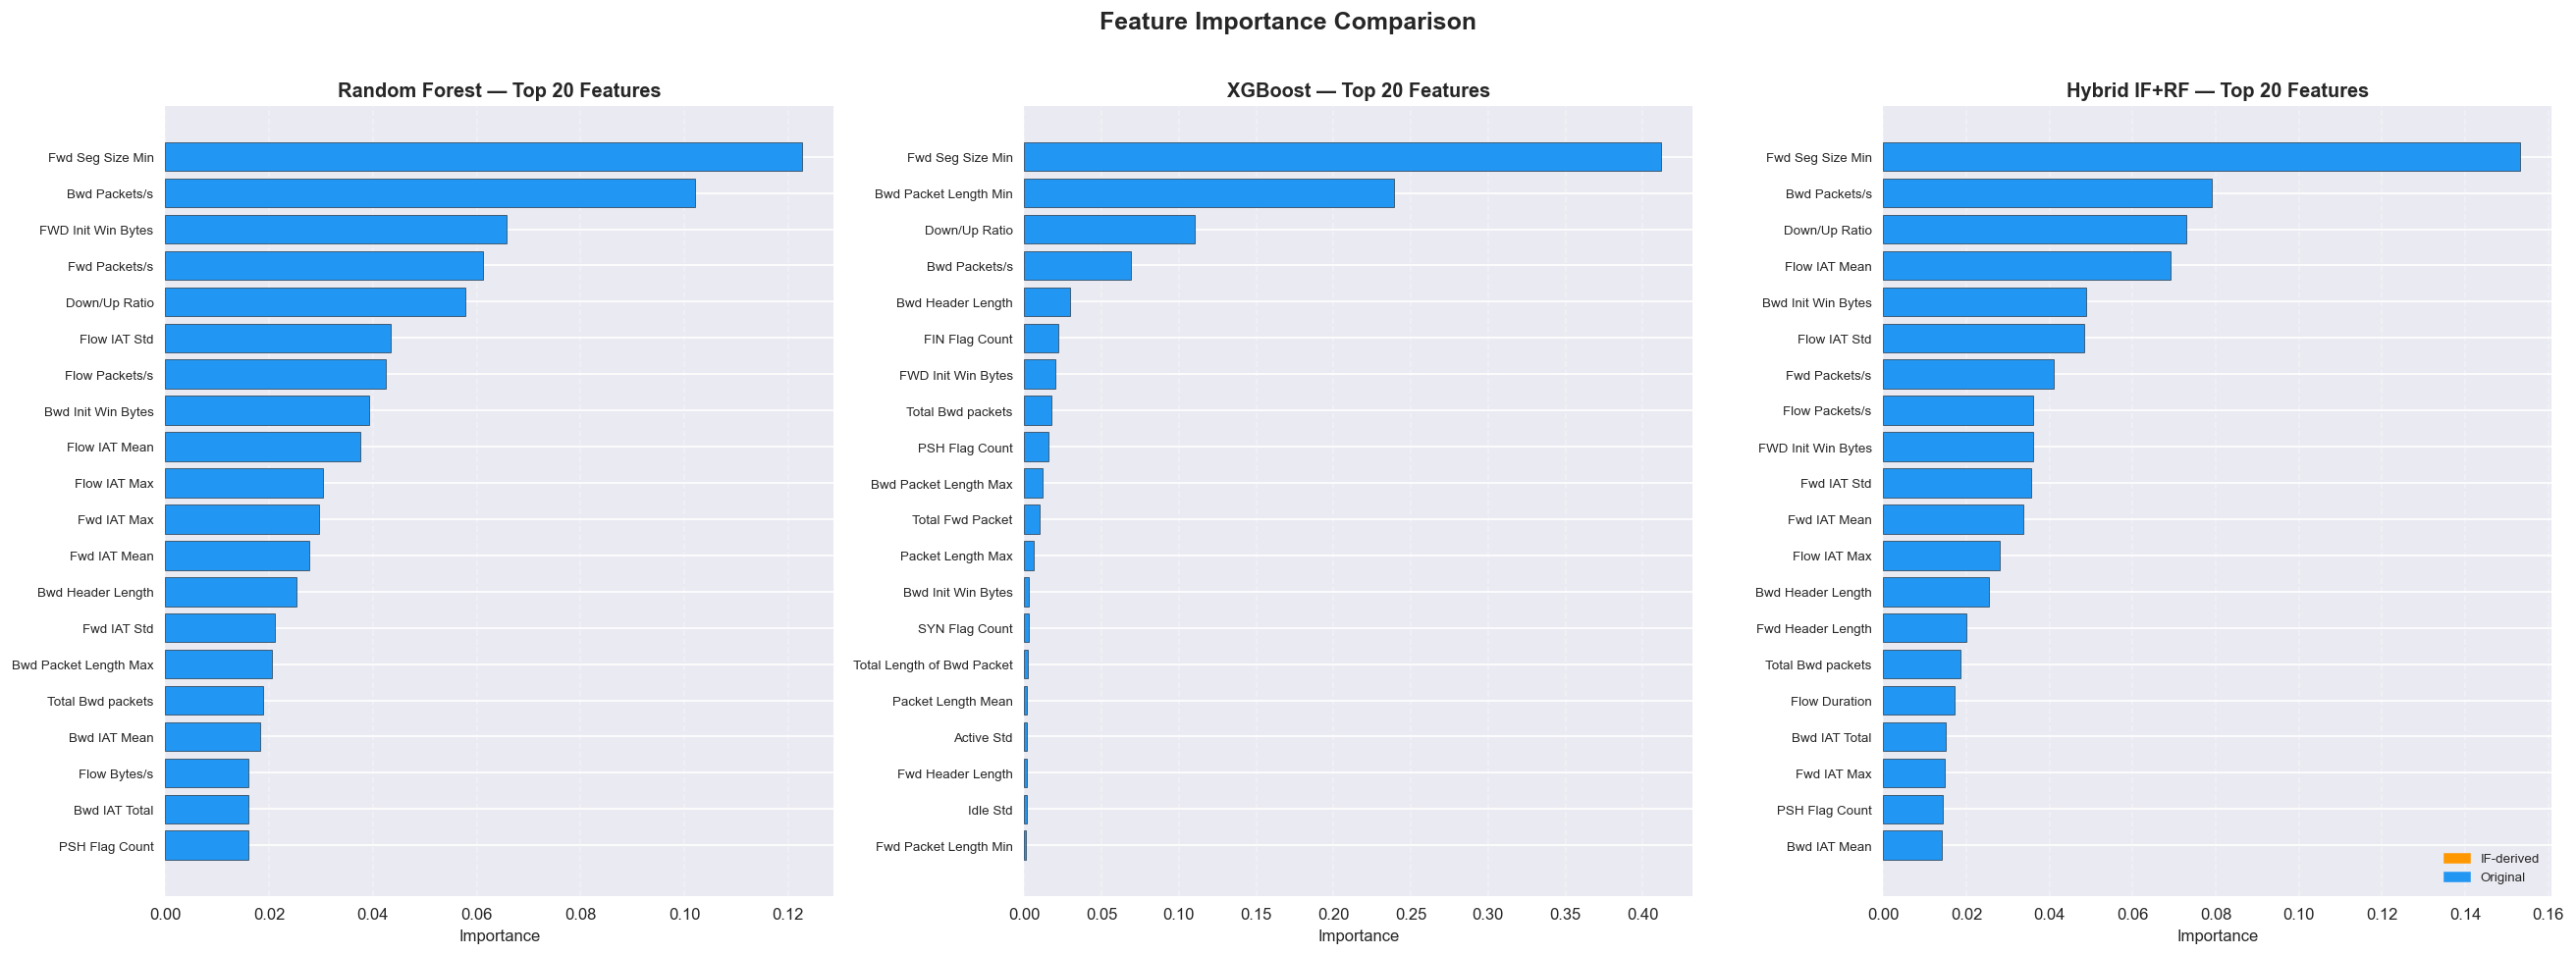

Saved to /Users/mac/Documents/TUS/Project/New/intelligent-nids/output/plots/comparison_feature_importance.png


In [20]:
top_n = 20
fi_models = {}

# Random Forest
imp_rf = rf_model.feature_importances_
idx_rf = np.argsort(imp_rf)[::-1][:top_n]
fi_models["Random Forest"] = (np.array(feature_cols)[idx_rf], imp_rf[idx_rf])

# XGBoost
imp_xgb = xgb_model.feature_importances_
idx_xgb = np.argsort(imp_xgb)[::-1][:top_n]
fi_models["XGBoost"] = (np.array(feature_cols)[idx_xgb], imp_xgb[idx_xgb])

# Hybrid IF+RF
fi_df_hybrid = hybrid_ifrf.get_feature_importances(feature_cols).head(top_n)
fi_models["Hybrid IF+RF"] = (fi_df_hybrid["feature"].values, fi_df_hybrid["importance"].values)

fig, axes = plt.subplots(1, 3, figsize=(22, 8))

for ax, (name, (names, imps)) in zip(axes, fi_models.items()):
    colors_fi = ["#FF9800" if "IF_" in n else "#2196F3" for n in names]
    ax.barh(range(len(names)), imps[::-1], color=colors_fi[::-1], edgecolor="black", lw=0.3)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names[::-1], fontsize=8)
    ax.set_xlabel("Importance", fontsize=10)
    ax.set_title(f"{name} — Top {top_n} Features", fontsize=12, fontweight="bold")
    ax.grid(axis="x", alpha=0.3, ls="--")

    if name == "Hybrid IF+RF":
        ax.legend(
            handles=[
                mpatches.Patch(color="#FF9800", label="IF-derived"),
                mpatches.Patch(color="#2196F3", label="Original"),
            ], fontsize=8, loc="lower right",
        )

fig.suptitle("Feature Importance Comparison", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"{PREFIX}_feature_importance.png", bbox_inches="tight")
plt.show()
print(f"Saved to {PLOTS_DIR / f'{PREFIX}_feature_importance.png'}")

### Visualisation 7 — t-SNE Comparison

Ground truth + one panel per model (subsampled to 2 000 points for speed).

Running t-SNE (main pipeline) on 2000 test samples …
Running t-SNE (KMeans/Hybrid PCA pipeline) on 2000 test samples …
t-SNE complete.


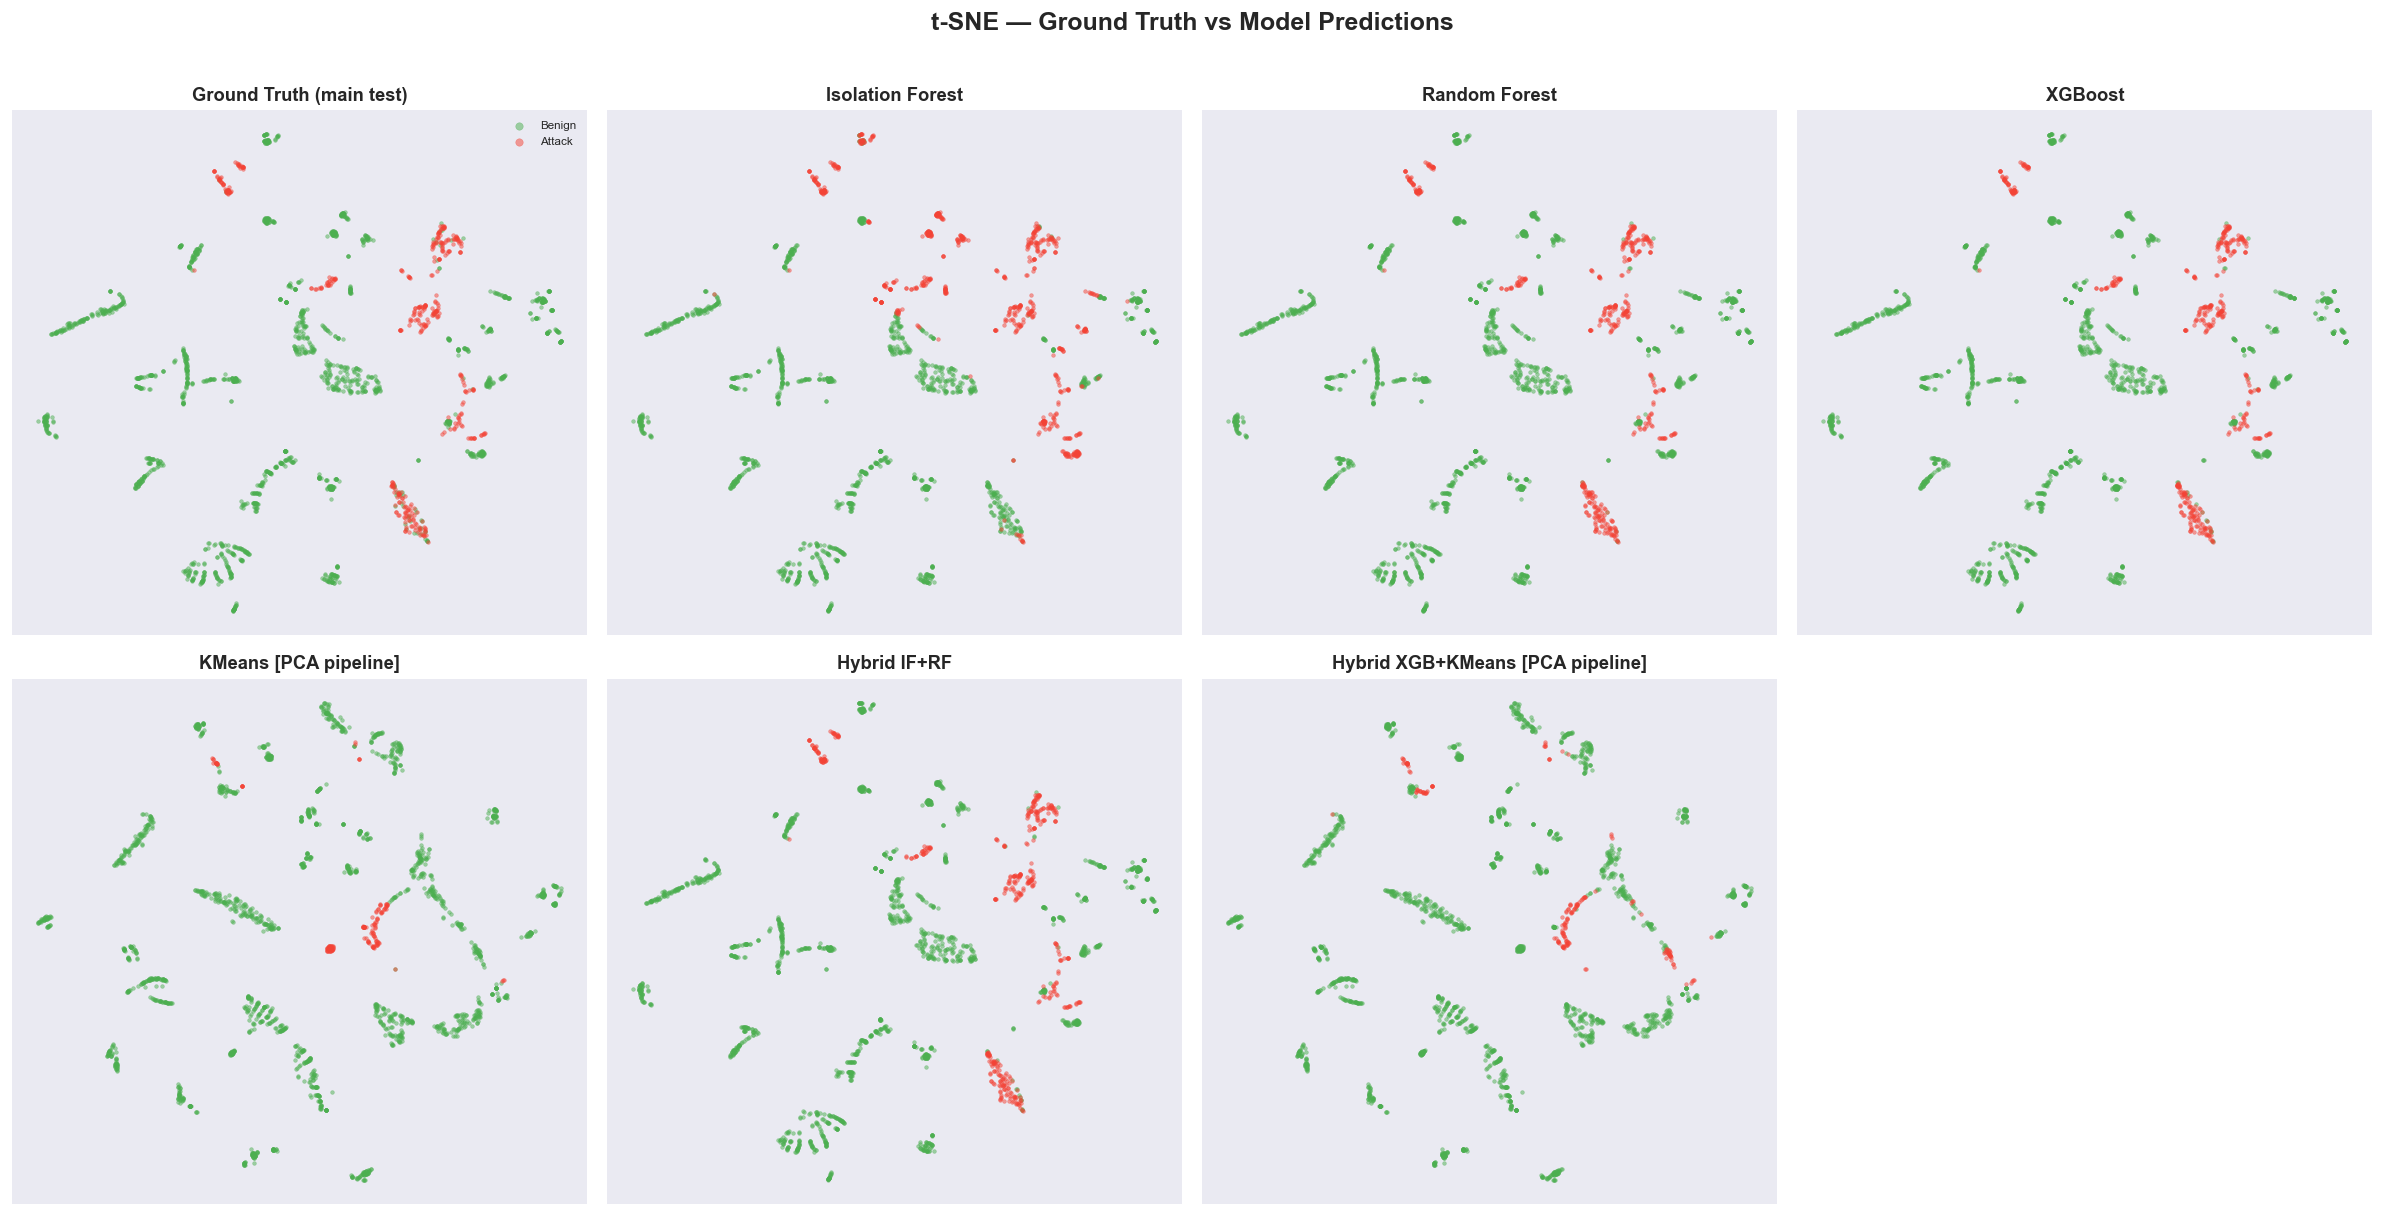

Saved to /Users/mac/Documents/TUS/Project/New/intelligent-nids/output/plots/comparison_tsne_comparison.png


In [21]:
# Two embeddings: main test (76-D scaled) vs KMeans/Hybrid pipeline (30-D PCA), different test sizes.
tsne_n_main = min(2000, X_test.shape[0])
tsne_n_km = min(2000, X_test_pca_km.shape[0])
rng = np.random.RandomState(SEED)
tsne_idx_main = rng.choice(X_test.shape[0], size=tsne_n_main, replace=False)
tsne_idx_km = rng.choice(X_test_pca_km.shape[0], size=tsne_n_km, replace=False)

print(f"Running t-SNE (main pipeline) on {tsne_n_main} test samples …")
X_tsne_main = TSNE(n_components=2, random_state=SEED, perplexity=30).fit_transform(
    X_test[tsne_idx_main]
)
print(f"Running t-SNE (KMeans/Hybrid PCA pipeline) on {tsne_n_km} test samples …")
X_tsne_km = TSNE(n_components=2, random_state=SEED, perplexity=30).fit_transform(
    X_test_pca_km[tsne_idx_km]
)
print("t-SNE complete.")

n_panels = 1 + len(MODEL_NAMES)
n_cols_tsne = 4
n_rows_tsne = (n_panels + n_cols_tsne - 1) // n_cols_tsne
fig, axes = plt.subplots(n_rows_tsne, n_cols_tsne, figsize=(5 * n_cols_tsne, 5 * n_rows_tsne))
axes = np.array(axes).flatten()

cmap = {0: "#4CAF50", 1: "#F44336"}

ax = axes[0]
yt0 = y_test[tsne_idx_main]
for label, color in cmap.items():
    mask = yt0 == 0 if label == 0 else yt0 != 0
    ax.scatter(X_tsne_main[mask, 0], X_tsne_main[mask, 1], c=color, s=5, alpha=0.5,
               label="Benign" if label == 0 else "Attack")
ax.set_title("Ground Truth (main test)", fontsize=11, fontweight="bold")
ax.legend(fontsize=7, markerscale=2)
ax.set_xticks([]); ax.set_yticks([])

for i, name in enumerate(MODEL_NAMES, start=1):
    ax = axes[i]
    use_km = name in ("KMeans", "Hybrid XGB+KMeans")
    X_tsne = X_tsne_km if use_km else X_tsne_main
    idx = tsne_idx_km if use_km else tsne_idx_main
    preds = results[name]["y_pred"][idx]
    pred_bin = (preds != 0).astype(int)
    for label, color in cmap.items():
        mask = pred_bin == label
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=color, s=5, alpha=0.5)
    ax.set_title(name + (" [PCA pipeline]" if use_km else ""), fontsize=11, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])

for j in range(n_panels, len(axes)):
    axes[j].axis("off")

fig.suptitle("t-SNE — Ground Truth vs Model Predictions", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"{PREFIX}_tsne_comparison.png", bbox_inches="tight")
plt.show()
print(f"Saved to {PLOTS_DIR / f'{PREFIX}_tsne_comparison.png'}")

### Visualisation 8 — Threshold Sensitivity Analysis

F1 / Precision / Recall vs decision threshold for models with probability outputs.

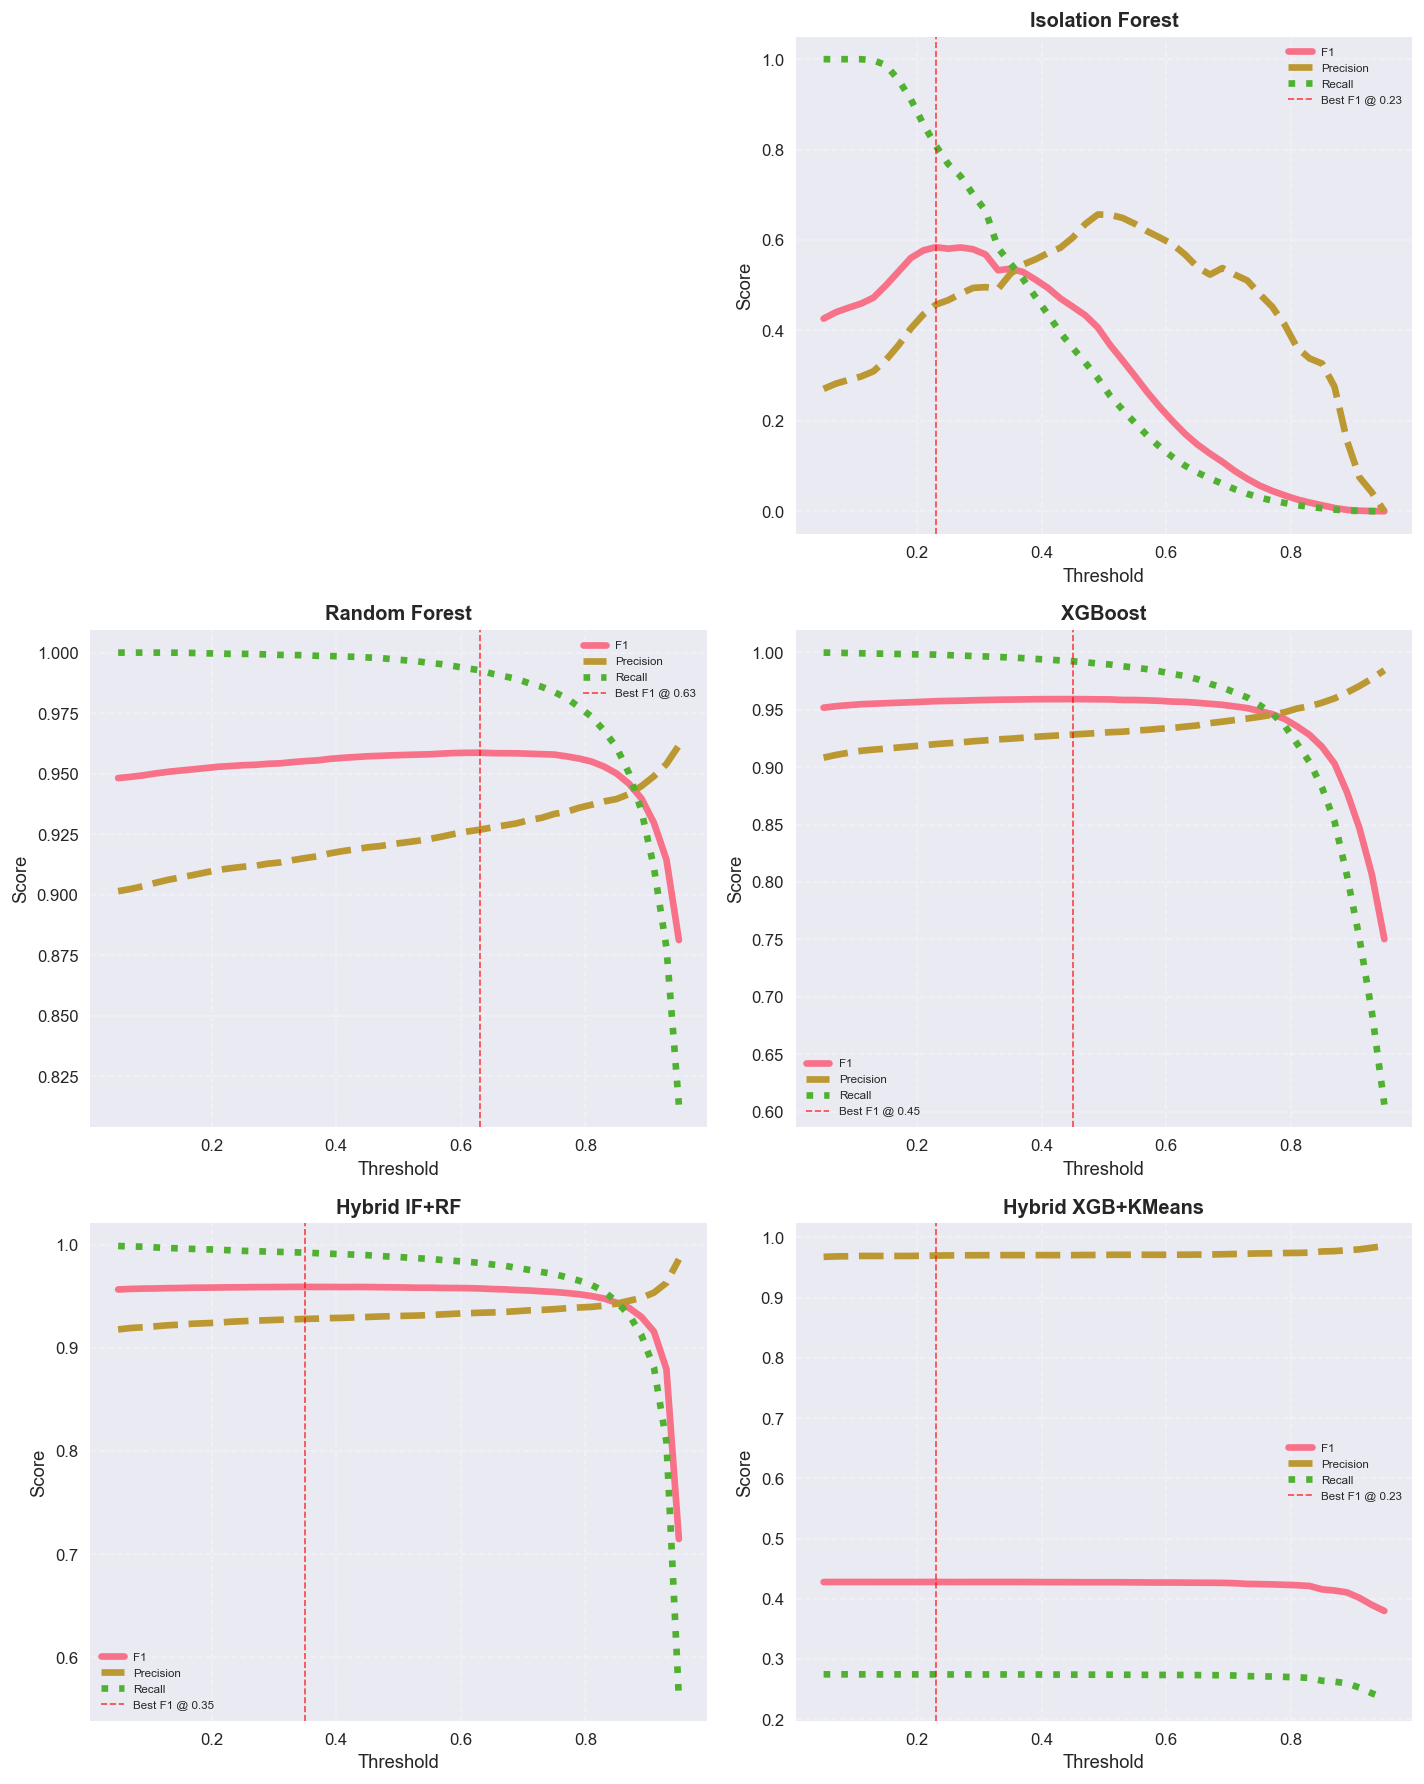

Saved to /Users/mac/Documents/TUS/Project/New/intelligent-nids/output/plots/comparison_threshold_sensitivity.png


In [22]:
thresholds = np.arange(0.05, 0.96, 0.02)
n_thresh_models = len(score_models)
n_rows_t = 3  # fixed: three rows
n_slots = n_thresh_models + 1  # +1: empty top-left cell
n_cols_t = (n_slots + n_rows_t - 1) // n_rows_t  # columns to fit all slots
fig, axes = plt.subplots(n_rows_t, n_cols_t, figsize=(6 * n_cols_t, 5 * n_rows_t))
axes = np.array(axes).flatten()
axes[0].axis("off")

for i, (name, scores) in enumerate(score_models.items()):
    ax = axes[i + 1]
    yt = y_true_for_model(name)
    y_bin = (np.asarray(yt) != 0).astype(int)
    f1s, precs, recs = [], [], []
    for t in thresholds:
        preds_t = (scores >= t).astype(int)
        f1s.append(f1_score(y_bin, preds_t, zero_division=0))
        precs.append(precision_score(y_bin, preds_t, zero_division=0))
        recs.append(recall_score(y_bin, preds_t, zero_division=0))

    ax.plot(thresholds, f1s, lw=4, label="F1")
    ax.plot(thresholds, precs, lw=4, label="Precision", ls="--")
    ax.plot(thresholds, recs, lw=4, label="Recall", ls=":")
    best_t = thresholds[np.argmax(f1s)]
    ax.axvline(best_t, color="red", ls="--", lw=1, alpha=0.7, label=f"Best F1 @ {best_t:.2f}")
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3, ls="--")

for j in range(n_thresh_models + 1, len(axes)):
    axes[j].axis("off")

# fig.suptitle("Threshold Sensitivity Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"{PREFIX}_threshold_sensitivity.png", bbox_inches="tight")
plt.show()
print(f"Saved to {PLOTS_DIR / f'{PREFIX}_threshold_sensitivity.png'}")

### Visualisation 9 — Performance Metrics Grouped Bar Chart

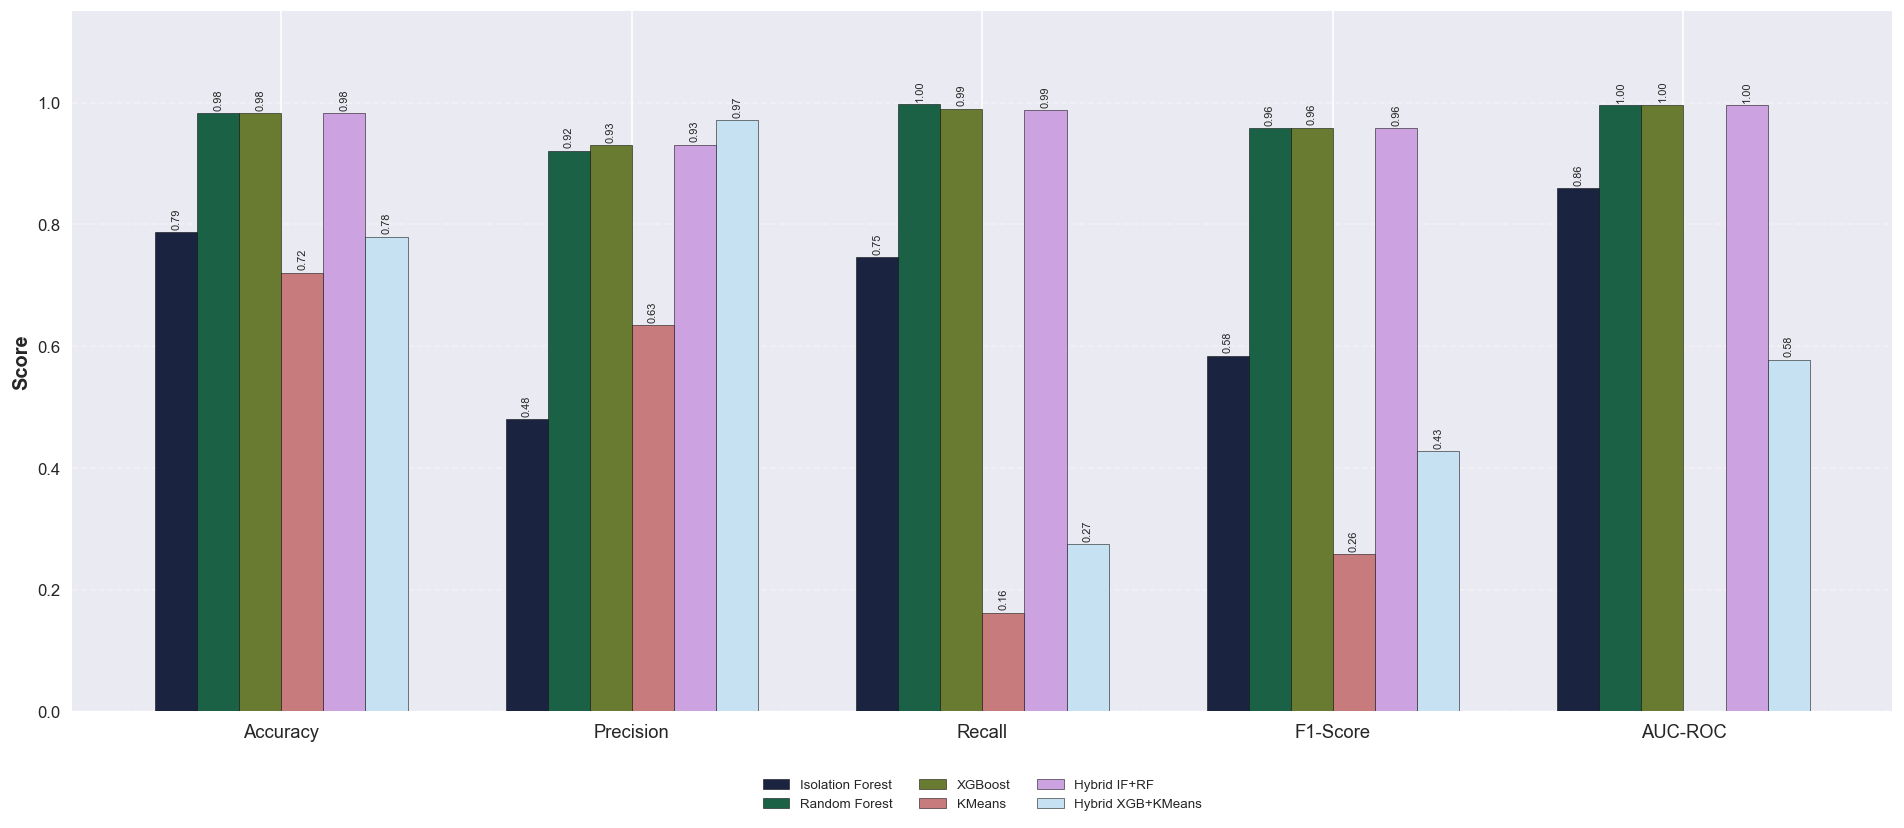

Saved to /Users/mac/Documents/TUS/Project/New/intelligent-nids/output/plots/comparison_metrics_bar.png


In [23]:
metric_keys = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]
n_metrics = len(metric_keys)
n_models = len(MODEL_NAMES)
x = np.arange(n_metrics)
width = 0.12

fig, ax = plt.subplots(figsize=(16, 7))
colors_bar = sns.color_palette("cubehelix", n_models)

for i, name in enumerate(MODEL_NAMES):
    row = metrics_df[metrics_df["Model"] == name].iloc[0]
    vals = [row[k] if row[k] is not None else 0 for k in metric_keys]
    bars = ax.bar(x + i * width, vals, width, label=name, color=colors_bar[i], edgecolor="black", lw=0.3)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f"{v:.2f}", ha="center", va="bottom", fontsize=6.5, rotation=90)

ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(metric_keys, fontsize=11)
ax.set_ylabel("Score", fontsize=12, fontweight="bold")
ax.set_ylim(0, 1.15)
# ax.set_title("Performance Metrics — All Models", fontsize=14, fontweight="bold")
ax.legend(fontsize=8, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.08))
ax.grid(axis="y", alpha=0.3, ls="--")

plt.tight_layout()
plt.savefig(PLOTS_DIR / f"{PREFIX}_metrics_bar.png", bbox_inches="tight")
plt.show()
print(f"Saved to {PLOTS_DIR / f'{PREFIX}_metrics_bar.png'}")

### Visualisation 10 — Radar / Spider Chart

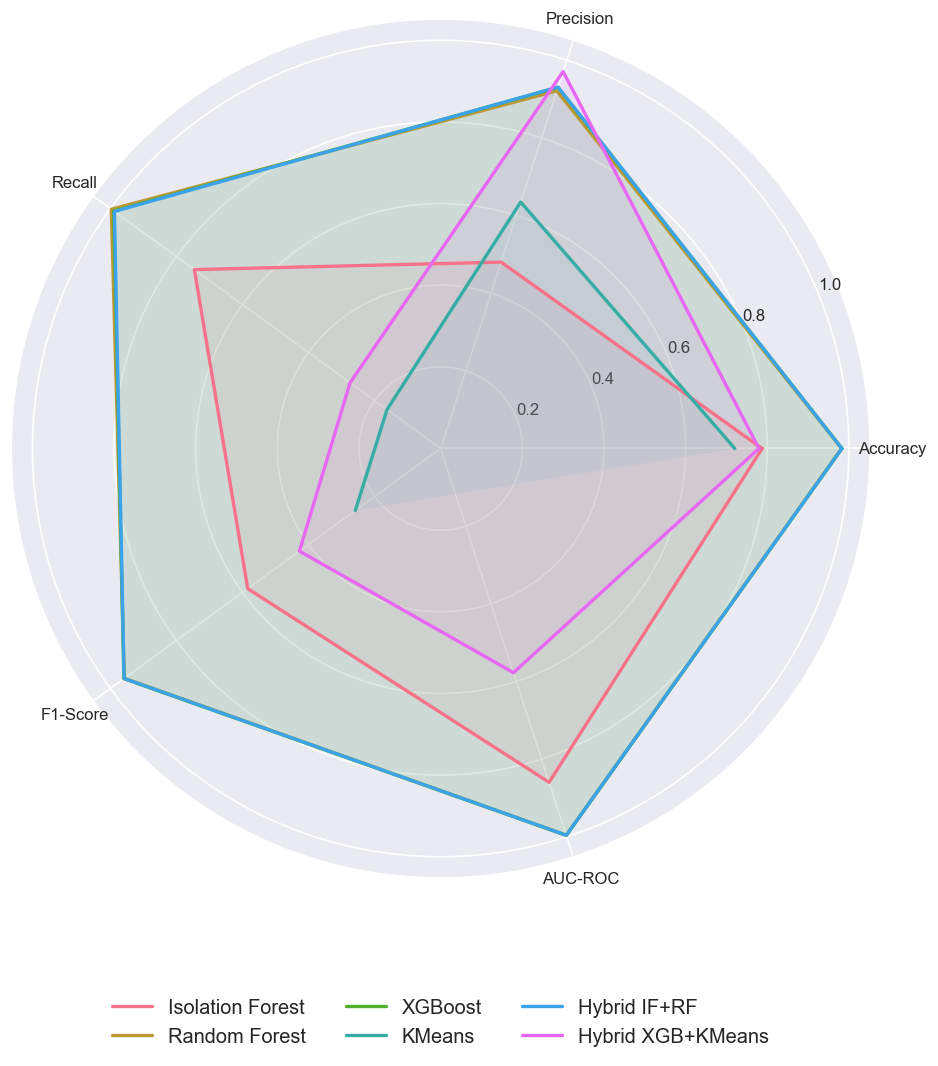

Saved to /Users/mac/Documents/TUS/Project/New/intelligent-nids/output/plots/comparison_radar_chart.png


In [24]:
radar_keys = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]
n_axes = len(radar_keys)
angles = np.linspace(0, 2 * np.pi, n_axes, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
colors_radar = sns.color_palette("husl", n_models)

for i, name in enumerate(MODEL_NAMES):
    row = metrics_df[metrics_df["Model"] == name].iloc[0]
    vals = [row[k] if row[k] is not None else 0 for k in radar_keys]
    vals += vals[:1]
    ax.plot(angles, vals, lw=2, label=name, color=colors_radar[i])
    ax.fill(angles, vals, alpha=0.08, color=colors_radar[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_keys, fontsize=10)
ax.set_ylim(0, 1.05)
# ax.set_title("Model Comparison — Radar Chart", fontsize=14, fontweight="bold", pad=20)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=min(n_models, 3), fontsize=12)

plt.tight_layout()
plt.savefig(PLOTS_DIR / f"{PREFIX}_radar_chart.png", bbox_inches="tight")
plt.show()
print(f"Saved to {PLOTS_DIR / f'{PREFIX}_radar_chart.png'}")

### Visualisation 11 — Error Analysis (FP & FN)

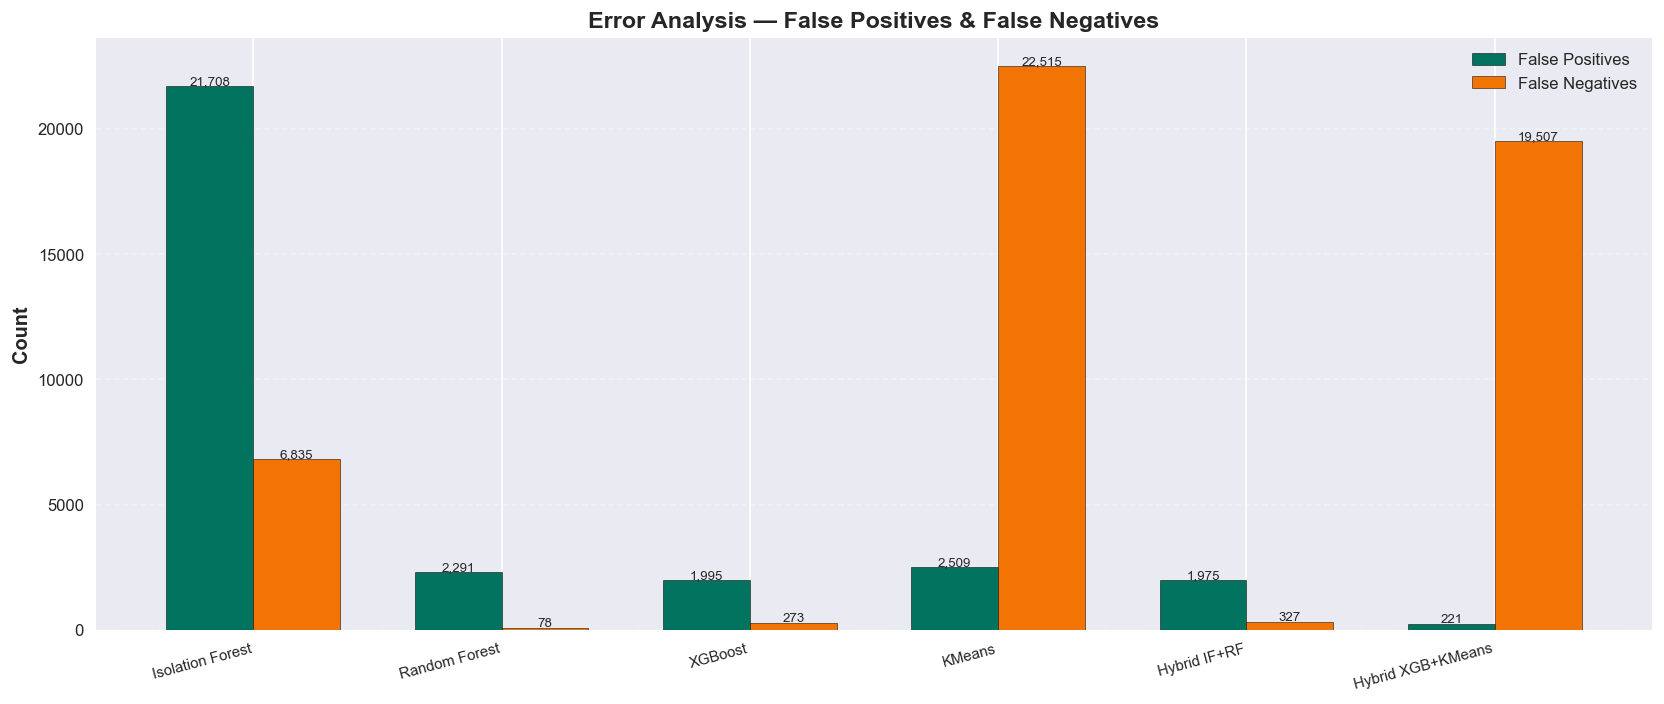

Saved to /Users/mac/Documents/TUS/Project/New/intelligent-nids/output/plots/comparison_error_analysis.png


In [25]:
fp_counts = metrics_df["FP"].values
fn_counts = metrics_df["FN"].values
model_labels = metrics_df["Model"].values

x_err = np.arange(len(model_labels))
w_err = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars_fp = ax.bar(x_err - w_err / 2, fp_counts, w_err, label="False Positives", color="#02735E", edgecolor="black", lw=0.3)
bars_fn = ax.bar(x_err + w_err / 2, fn_counts, w_err, label="False Negatives", color="#F27405", edgecolor="black", lw=0.3)

for bar in bars_fp:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f"{int(bar.get_height()):,}", ha="center", fontsize=8)
for bar in bars_fn:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f"{int(bar.get_height()):,}", ha="center", fontsize=8)

ax.set_xticks(x_err)
ax.set_xticklabels(model_labels, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Count", fontsize=12, fontweight="bold")
ax.set_title("Error Analysis — False Positives & False Negatives", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3, ls="--")

plt.tight_layout()
plt.savefig(PLOTS_DIR / f"{PREFIX}_error_analysis.png", bbox_inches="tight")
plt.show()
print(f"Saved to {PLOTS_DIR / f'{PREFIX}_error_analysis.png'}")

### Visualisation 12 — Model Ranking Heatmap

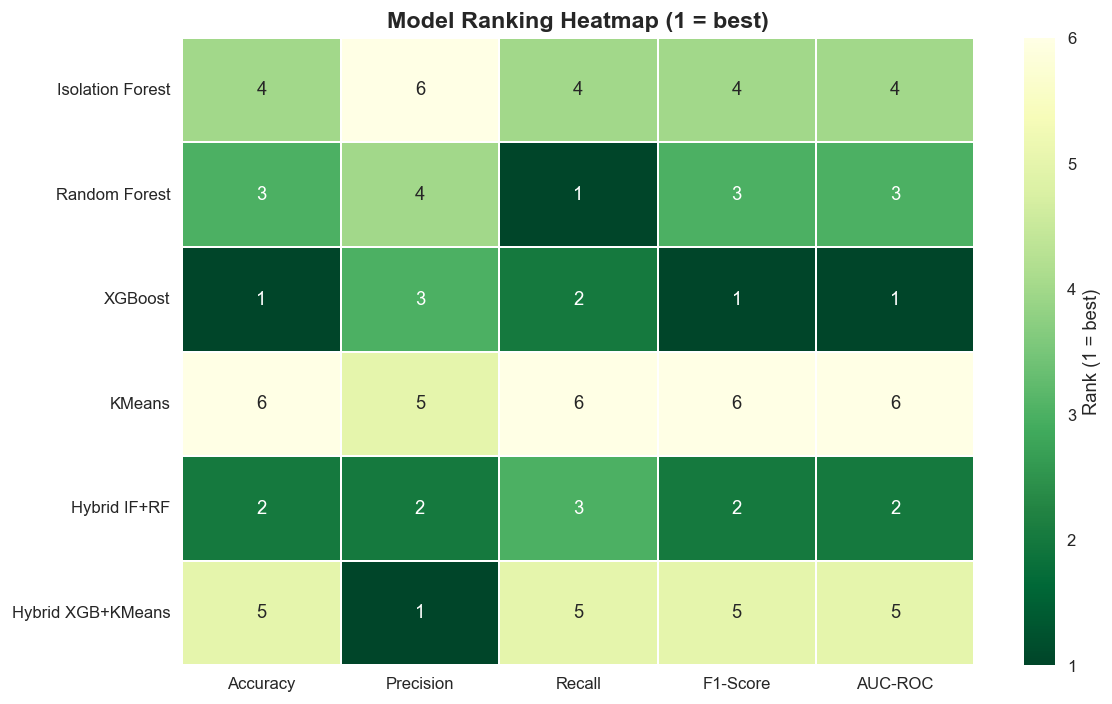

Saved to /Users/mac/Documents/TUS/Project/New/intelligent-nids/output/plots/comparison_model_ranking.png


In [26]:
rank_cols = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]
rank_df = metrics_df[["Model"] + rank_cols].copy()

for col in rank_cols:
    vals = rank_df[col].copy()
    vals = vals.fillna(0)
    rank_df[col + "_rank"] = vals.rank(ascending=False, method="min").astype(int)

rank_matrix = rank_df[[col + "_rank" for col in rank_cols]].values
rank_labels = rank_df["Model"].values

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(rank_matrix, annot=True, fmt="d", cmap="YlGn_r",
            xticklabels=rank_cols, yticklabels=rank_labels,
            linewidths=1, linecolor="white", cbar_kws={"label": "Rank (1 = best)"},
            ax=ax)
ax.set_title("Model Ranking Heatmap (1 = best)", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig(PLOTS_DIR / f"{PREFIX}_model_ranking.png", bbox_inches="tight")
plt.show()
print(f"Saved to {PLOTS_DIR / f'{PREFIX}_model_ranking.png'}")

## 7 — Summary & Conclusions

In [27]:
print("=" * 70)
print("SUMMARY — Best model per metric")
print("=" * 70)

summary_metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]
for m in summary_metrics:
    col = metrics_df[m].copy()
    col = col.fillna(0)
    best_idx = col.idxmax()
    best_model = metrics_df.loc[best_idx, "Model"]
    best_val = metrics_df.loc[best_idx, m]
    val_str = f"{best_val:.4f}" if best_val is not None else "N/A"
    print(f"  {m:15s}:  {best_model}  ({val_str})")

overall_best_idx = metrics_df["F1-Score"].idxmax()
overall_best = metrics_df.loc[overall_best_idx, "Model"]
overall_f1 = metrics_df.loc[overall_best_idx, "F1-Score"]
overall_auc = metrics_df.loc[overall_best_idx, "AUC-ROC"]
auc_str = f"{overall_auc:.4f}" if overall_auc is not None else "N/A"

print()
print("=" * 70)
print(f"OVERALL RECOMMENDATION (by F1-Score):  {overall_best}")
print(f"  F1-Score = {overall_f1:.4f}   |   AUC-ROC = {auc_str}")
print("=" * 70)

print("\nAll 12 comparison figures saved to:", PLOTS_DIR)
print("Prefix:", PREFIX)

SUMMARY — Best model per metric
  Accuracy       :  XGBoost  (0.9831)
  Precision      :  Hybrid XGB+KMeans  (0.9709)
  Recall         :  Random Forest  (0.9971)
  F1-Score       :  XGBoost  (0.9591)
  AUC-ROC        :  XGBoost  (0.9965)

OVERALL RECOMMENDATION (by F1-Score):  XGBoost
  F1-Score = 0.9591   |   AUC-ROC = 0.9965

All 12 comparison figures saved to: /Users/mac/Documents/TUS/Project/New/intelligent-nids/output/plots
Prefix: comparison


### Key Takeaways

1. **Supervised models** (Random Forest, XGBoost, Hybrid IF+RF) generally outperform unsupervised ones (Isolation Forest, KMeans) on labelled data.
2. **Hybrid IF+RF** combines the best of both worlds — the IF anomaly score enriches the RF feature space, often yielding top F1 and AUC-ROC scores.
3. **Isolation Forest** alone has high recall but lower precision (many false positives), making it more suitable as a first-stage filter.
4. **KMeans** lacks probability outputs, limiting its use in threshold-tuning and ROC analysis, but still provides a useful unsupervised baseline.
5. The **radar chart** and **ranking heatmap** make it easy to see which model dominates across multiple metrics simultaneously.
6. **Error analysis** reveals the FP / FN trade-off: models optimised for recall may produce more false positives, while precision-focused models miss more attacks.